In [1]:
import xarray as xr
import json
import pandas as pd
import torch
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import os
import sys
sys.path.append('../')
import utils.evaluation as evaluation
import utils.utils as ut

In [2]:
# load true test data
settings_file_path = "../../settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
no_epochs=settings['epochs']


### Factual ###

### Load temperature TEST data ###
ds_test_eth_fact_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_transient']) # add 3 times climatology here
ds_test_eth_fact_pre = xr.open_dataset(ds_test_eth_fact_path)
print(ds_test_eth_fact_pre) #lat,lon,time

# load climatologies
clim_eth_1300_pre=xr.open_dataset("/work2/fl53wumy-ws_new/fl53wumy-fl53wumy-llaae_ws_new-1779067202-1785633601/fl53wumy-llaae_ws_new-1779067202/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/TREFHT_day_b.e212.BHISTcmip6_BSSP370cmip6.f09_g17.1300_1850-2100_clim.nc")
clim_eth_1400_pre=xr.open_dataset("/work2/fl53wumy-ws_new/fl53wumy-fl53wumy-llaae_ws_new-1779067202-1785633601/fl53wumy-llaae_ws_new-1779067202/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/TREFHT_day_b.e212.BHISTcmip6_BSSP370cmip6.f09_g17.1400_1850-2100_clim.nc")
clim_eth_1500_pre=xr.open_dataset("/work2/fl53wumy-ws_new/fl53wumy-fl53wumy-llaae_ws_new-1779067202-1785633601/fl53wumy-llaae_ws_new-1779067202/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/TREFHT_day_b.e212.BHISTcmip6_BSSP370cmip6.f09_g17.1500_1850-2100_clim.nc")
clim_eth_1500_pre

# subset
eth_1300_clim = clim_eth_1300_pre.assign_coords(lon=((clim_eth_1300_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_1400_clim = clim_eth_1400_pre.assign_coords(lon=((clim_eth_1400_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_1500_clim = clim_eth_1500_pre.assign_coords(lon=((clim_eth_1500_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_1300_clim #time,lat,lon

# bring climatologies into right order
combined_climatologies = np.concatenate([np.transpose(np.tile(eth_1300_clim.TREFHT.values, (251,1,1)), (1,2,0)), 
                                         np.transpose(np.tile(eth_1400_clim.TREFHT.values, (251,1,1)), (1,2,0)), 
                                         np.transpose(np.tile(eth_1500_clim.TREFHT.values, (251,1,1)), (1,2,0))], 
                                        axis=2)
print(combined_climatologies.shape)

# add climatology
ds_test_eth_fact = ds_test_eth_fact_pre.TREFHT + combined_climatologies - 273.15
ds_test_eth_fact

# load DAE ensemble
# current
dae_ensemble_fact = f"{settings['current_model']}/dae_ensemble_after_{no_epochs}_epochs/ETH_ensemble_after_{no_epochs}_epochs/ETH_gen_dpa_ens_{no_epochs}_dataset_restored.nc"
dae_eth_fact_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_fact)


dae_eth_fact = xr.open_dataset(dae_eth_fact_path) + np.transpose(combined_climatologies, (2,0,1)) - 273.15
dae_eth_fact

# load nudged climatologies
# load climatologies
clim_eth_cf_1300_pre=xr.open_dataset("/work2/fl53wumy-ws_new/fl53wumy-fl53wumy-llaae_ws_new-1779067202-1785633601/fl53wumy-llaae_ws_new-1779067202/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/TREFHT_day_b.e212.B1850cmip6.f09_g17.001.nudge-1850-2100-SSP370.1300.linear-weak_shifted-1day_clim.nc")
clim_eth_cf_1400_pre=xr.open_dataset("/work2/fl53wumy-ws_new/fl53wumy-fl53wumy-llaae_ws_new-1779067202-1785633601/fl53wumy-llaae_ws_new-1779067202/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/TREFHT_day_b.e212.B1850cmip6.f09_g17.001.nudge-1850-2100-SSP370.1400.linear-weak_shifted-1day_clim.nc")
clim_eth_cf_1500_pre=xr.open_dataset("/work2/fl53wumy-ws_new/fl53wumy-fl53wumy-llaae_ws_new-1779067202-1785633601/fl53wumy-llaae_ws_new-1779067202/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/TREFHT_day_b.e212.B1850cmip6.f09_g17.001.nudge-1850-2100-SSP370.1500.linear-weak_shifted-1day_clim.nc")
clim_eth_cf_1500_pre

# subset
eth_cf_1300_clim = clim_eth_cf_1300_pre.assign_coords(lon=((clim_eth_cf_1300_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_cf_1400_clim = clim_eth_cf_1400_pre.assign_coords(lon=((clim_eth_cf_1400_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_cf_1500_clim = clim_eth_cf_1500_pre.assign_coords(lon=((clim_eth_cf_1500_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_cf_1300_clim #time,lat,lon

# bring climatologies into right order
combined_climatologies_cf = np.concatenate([np.transpose(np.tile(eth_cf_1300_clim.TREFHT.values, (251,1,1)), (1,2,0)), 
                                         np.transpose(np.tile(eth_cf_1400_clim.TREFHT.values, (251,1,1)), (1,2,0)), 
                                         np.transpose(np.tile(eth_cf_1500_clim.TREFHT.values, (251,1,1)), (1,2,0))], 
                                        axis=2)

### Load counterfactual temperature TEST data ###
ds_test_eth_cf_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_nudged_shifted'])
ds_test_eth_cf_pre = xr.open_dataset(ds_test_eth_cf_path)
ds_test_eth_cf = ds_test_eth_cf_pre.TREFHT + combined_climatologies_cf - 273.15
ds_test_eth_cf

### Counterfactual ###
# load DAE ensemble
# load DAE ensemble
# current
dae_ensemble_cf = f"{settings['current_model']}/dae_ensemble_after_{no_epochs}_epochs/ETH_ensemble_after_{no_epochs}_epochs/ETH_cf_gen_dpa_ens_{no_epochs}_dataset_restored.nc"
dae_eth_cf_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_cf)


dae_eth_cf = xr.open_dataset(dae_eth_cf_path) + np.transpose(combined_climatologies, (2,0,1)) - 273.15
dae_eth_cf

# compute domain average temperature
dae_eth_ens_spatial_mean = dae_eth_fact.TREFHT.mean(dim=("lat","lon"))
dae_eth_ens_spatial_mean_cf = dae_eth_cf.TREFHT.mean(dim=("lat","lon"))

# mean
#fact_dae_mean = dae_eth_fact.TREFHT.mean(dim="ensemble_member")
#cf_dae_mean = dae_eth_cf.TREFHT.mean(dim="ensemble_member")



<xarray.Dataset> Size: 59MB
Dimensions:  (lat: 32, lon: 32, time: 14307)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 59MB ...
(32, 32, 14307)


In [3]:
##################
### set domain ###
##################
# FRANCE
fr_lat_min = 45
fr_lat_max = 50
fr_lon_min= 0
fr_lon_max= 5

## Bias

In [4]:
def old_weighted_domain_mean(da, lat_min, lat_max, lon_min, lon_max):
    """Latitude-weighted spatial mean over a rectangular domain."""
    da_domain = da.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max),
    )

    weights = np.cos(np.deg2rad(da_domain["lat"]))
    weights = xr.DataArray(
        weights,
        coords={"lat": da_domain["lat"]},
        dims=["lat"],
    )

    return da_domain.weighted(weights).mean(dim=("lat", "lon"))

def weighted_domain_mean(da, lat_min=None, lat_max=None, lon_min=None, lon_max=None):
    """Latitude-weighted spatial mean over a rectangular domain.

    If any of lat_min, lat_max, lon_min, lon_max are None, the mean is
    computed over the entire domain along that dimension.
    """
    da_domain = da.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max),
    )
    weights = np.cos(np.deg2rad(da_domain["lat"]))
    weights = xr.DataArray(
        weights,
        coords={"lat": da_domain["lat"]},
        dims=["lat"],
    )
    return da_domain.weighted(weights).mean(dim=("lat", "lon"))

# include coordinates for using subdomain
# truth
x_eth_fact_reduced_mean = weighted_domain_mean(ds_test_eth_fact) #, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)
x_eth_cf_reduced_mean = weighted_domain_mean(ds_test_eth_cf) #, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)

# DAE
dae_eth_ens_spatial_mean = weighted_domain_mean(dae_eth_fact) #, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)
dae_eth_ens_spatial_mean_cf = weighted_domain_mean(dae_eth_cf) #, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)

In [5]:
# Truth
weights = np.cos(np.deg2rad(ds_test_eth_fact.lat))
x_eth_fact_reduced_mean_numpy = x_eth_fact_reduced_mean.values

# Counterfactual ERA5 test data
weights = np.cos(np.deg2rad(ds_test_eth_cf.lat))
x_eth_cf_reduced_mean_numpy = x_eth_cf_reduced_mean.values

######################################################
# DAE ensemble spat means

# absolute temps
dpa_eth_fact_ensemble_spat_mean = dae_eth_ens_spatial_mean #dpa_ensemble_fact_raw.TREFHT.mean(dim="lat_x_lon")
dpa_eth_cf_ensemble_spat_mean = dae_eth_ens_spatial_mean_cf #dpa_ensemble_raw_cf.TREFHT.mean(dim="lat_x_lon")

######################################################

# DAE ensemble mean spat mean
dpa_eth_fact_ensemble_mean_spat_mean = dpa_eth_fact_ensemble_spat_mean.mean(dim="ensemble_member")
dpa_eth_cf_ensemble_mean_spat_mean = dpa_eth_cf_ensemble_spat_mean.mean(dim="ensemble_member")
dpa_eth_cf_ensemble_mean_spat_mean


print("ERA5 test shapes:", x_eth_fact_reduced_mean_numpy.shape, x_eth_cf_reduced_mean_numpy.shape)
test_sets = [x_eth_fact_reduced_mean_numpy, x_eth_cf_reduced_mean_numpy]
dpa_spat_means = [dpa_eth_fact_ensemble_spat_mean, dpa_eth_cf_ensemble_spat_mean]
dae_ensemble_means_spat_means = [dpa_eth_fact_ensemble_mean_spat_mean, dpa_eth_cf_ensemble_mean_spat_mean]

ERA5 test shapes: (14307,) (14307,)


(4769,)


/tmp/ipykernel_1666655/3348913483.py:5: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time = x_eth_fact_reduced_mean.indexes["time"].to_datetimeindex()[0:4769]
/tmp/ipykernel_1666655/3348913483.py:5: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time = x_eth_fact_reduced_mean.indexes["time"].to_datetimeindex()[0:4769]


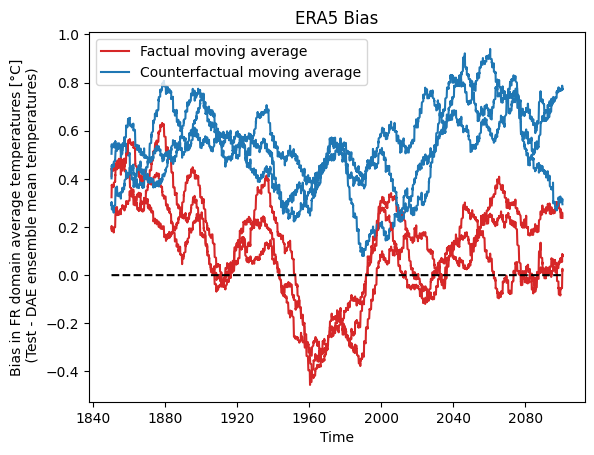

In [6]:
temporal_era5_bias_fact = x_eth_fact_reduced_mean.values - dpa_eth_fact_ensemble_mean_spat_mean.TREFHT.values
temporal_era5_bias_cf = x_eth_cf_reduced_mean - dpa_eth_cf_ensemble_mean_spat_mean.assign_coords(time=x_eth_cf_reduced_mean.time)
temporal_era5_bias_cf

time = x_eth_fact_reduced_mean.indexes["time"].to_datetimeindex()[0:4769]
print(time.shape)

#plt.scatter(time, temporal_era5_bias_fact, color="tab:red", marker='.', alpha=0.2, s=5)
#plt.scatter(time, temporal_era5_bias_cf.TREFHT.values, color="tab:blue", marker='.', alpha=0.2, s=5)
#temporal_era5_bias_fact.plot.scatter()

def moving_average_edge(x, window):
    kernel = np.ones(window)
    
    # Convolve data
    smoothed = np.convolve(x, kernel, mode='same')
    
    # Convolve ones to count how many valid points contribute at each position
    counts = np.convolve(np.ones_like(x), kernel, mode='same')
    
    return smoothed / counts

window = 200
# 1300
smooth_era5_bias_fact_1300 = moving_average_edge(temporal_era5_bias_fact[0:4769],window)
smooth_era5_bias_cf_1300 = moving_average_edge(temporal_era5_bias_cf.TREFHT.isel(time=slice(0,4769)).values, window)

# 1400
smooth_era5_bias_fact_1400 = moving_average_edge(temporal_era5_bias_fact[4769:2*4769], window)
smooth_era5_bias_cf_1400 = moving_average_edge(temporal_era5_bias_cf.TREFHT.isel(time=slice(4769,2*4769)).values, window)

# 1500
smooth_era5_bias_fact_1500 = moving_average_edge(temporal_era5_bias_fact[2*4769:3*4769], window)
smooth_era5_bias_cf_1500 = moving_average_edge(temporal_era5_bias_cf.TREFHT.isel(time=slice(2*4769,3*4769)).values, window)

plt.plot(time, smooth_era5_bias_fact_1300, color="tab:red", label="Factual moving average")
plt.plot(time, smooth_era5_bias_cf_1300, color="tab:blue", label="Counterfactual moving average")

plt.plot(time, smooth_era5_bias_fact_1400, color="tab:red")
plt.plot(time, smooth_era5_bias_cf_1400, color="tab:blue")

plt.plot(time, smooth_era5_bias_fact_1500, color="tab:red")
plt.plot(time, smooth_era5_bias_cf_1500, color="tab:blue")



plt.plot(time, np.zeros(4769), color='k', linestyle='--')
#plt.ylim(-2.5,2.5)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Bias in FR domain average temperatures [°C]\n (Test - DAE ensemble mean temperatures)")
plt.title("ERA5 Bias")
#plt.savefig(f"/home/sc.uni-leipzig.de/fl53wumy/llaae_new/TowardsDistributionalAutoencoderClimateCounterfactuals/figures/model_6037/ETH_test_data_entire_domain_time_resolved_bias.pdf")
plt.show()

## Maps

In [4]:
date = 2808 #=year 2036
year = 1997
hw_month = "08"
hw_day = "16"



# date = 1506  # 2019-06-27
# year = 2019
# hw_month = "06"
# hw_day = "27"

date_text = f"{year}-{hw_month}-{hw_day}"

print("Date:", ds_test_eth_fact.isel(time=date).time.values)

Date: 1997-08-16 00:00:00


Date: 1997-08-16 00:00:00


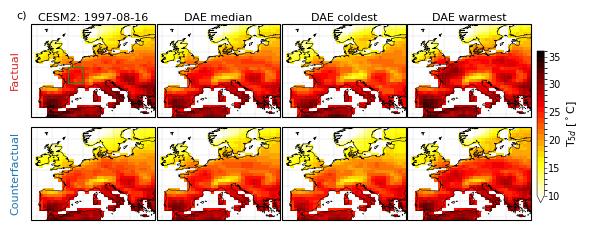

In [7]:
# for SI using median



import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------------------------------------------------------------
# Domain
# ---------------------------------------------------------------------
# GER domain
#ger_lat_min = 48
#ger_lat_max = 54
#ger_lon_min = 6
#ger_lon_max = 15

# FRANCE
ger_lat_min = 45
ger_lat_max = 50
ger_lon_min= 0
ger_lon_max= 5


# ---------------------------------------------------------------------
# Publication figure settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.42

FONT_SIZE = 8

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE - 1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------------------------------------------------
# Select event
# ---------------------------------------------------------------------
date = 2808 #3000 #=year 2036
year = 1997
hw_month = "08"
hw_day = "16"



# date = 1506  # 2019-06-27
# year = 2019
# hw_month = "06"
# hw_day = "27"

date_text = f"{year}-{hw_month}-{hw_day}"

print("Date:", ds_test_eth_fact.isel(time=date).time.values)

# ---------------------------------------------------------------------
# Compute ensemble means
# ---------------------------------------------------------------------
fact_dae_mean = dae_eth_fact.TREFHT#.mean(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.TREFHT#.mean(dim="ensemble_member")

# ---------------------------------------------------------------------
# Find coldest / warmest members
# ---------------------------------------------------------------------
imin_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmin(dim="ensemble_member")
)

imax_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

imin_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmin(dim="ensemble_member")
)

imax_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

# ---------------------------------------------------------------------
# Fields
# ---------------------------------------------------------------------
fields = [
    # factual
    ds_test_eth_fact.isel(time=date),
    fact_dae_mean.isel(time=date).median(dim="ensemble_member"),
    dae_eth_fact.TREFHT.isel(ensemble_member=imin_fact, time=date),
    dae_eth_fact.TREFHT.isel(ensemble_member=imax_fact, time=date),

    # counterfactual
    ds_test_eth_cf.isel(time=date),
    cf_dae_mean.isel(time=date).median(dim="ensemble_member"),
    dae_eth_cf.TREFHT.isel(ensemble_member=imin_cf, time=date),
    dae_eth_cf.TREFHT.isel(ensemble_member=imax_cf, time=date),
]

titles = [
    f"CESM2: {date_text}",
    "DAE median",
    "DAE coldest",
    "DAE warmest",
    "",
    "",
    "",
    "",
]

# ---------------------------------------------------------------------
# Plot settings
# ---------------------------------------------------------------------
vmin = 10
vmax = 36

# finer contour levels
levels = np.linspace(vmin, vmax, 27)

# sparse colorbar ticks
cbar_ticks = np.arange(10, 37, 5)

cmap = "hot_r"

# France domain box
box_lat_min = 45
box_lat_max = 50
box_lon_min = 0
box_lon_max = 5

box_lons = [
    box_lon_min,
    box_lon_max,
    box_lon_max,
    box_lon_min,
    box_lon_min,
]

box_lats = [
    box_lat_min,
    box_lat_min,
    box_lat_max,
    box_lat_max,
    box_lat_min,
]

# ---------------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    4,
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=False,
)

axes = axes.ravel()

# ---------------------------------------------------------------------
# Plot panels
# ---------------------------------------------------------------------
for i, (ax, field, title) in enumerate(zip(axes, fields, titles)):

    # background
    ax.add_feature(
        cfeature.LAND,
        facecolor="0.88",
        edgecolor="none",
        zorder=0,
    )

    ax.coastlines(
        resolution="50m",
        linewidth=0.4,
        zorder=3,
    )

    # temperature field
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        levels=levels,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        rasterized=True,
        zorder=2,
    )

    # domain box
    if i == 0:
        ax.plot(
            box_lons,
            box_lats,
            transform=ccrs.PlateCarree(),
            color="forestgreen",
            linewidth=0.8,
            zorder=4,
        )

    # subtle gridlines
    ax.gridlines(
        draw_labels=False,
        linewidth=0.25,
        color="0.5",
        alpha=0.5,
        linestyle="--",
        zorder=1,
    )

    ax.set_title(title, pad=2)

# ---------------------------------------------------------------------
# Row labels
# ---------------------------------------------------------------------
axes[0].text(
    -0.13,
    0.5,
    "Factual",
    transform=axes[0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    color="tab:red",
)

axes[4].text(
    -0.13,
    0.5,
    "Counterfactual",
    transform=axes[4].transAxes,
    rotation=90,
    va="center",
    ha="center",
    color="tab:blue",
)

# ---------------------------------------------------------------------
# Panel label
# ---------------------------------------------------------------------
axes[0].text(
    -0.12,
    1.04,
    "c)",
    transform=axes[0].transAxes,
    va="bottom",
    ha="left",
)

# ---------------------------------------------------------------------
# Layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.055,
    right=0.885,
    bottom=0.10,
    top=0.90,
    wspace=0.015,
    hspace=0.04,
)

# ---------------------------------------------------------------------
# Discrete colorbar
# ---------------------------------------------------------------------
cax = fig.add_axes([0.895, 0.18, 0.012, 0.60])

cbar = fig.colorbar(
    pc,
    cax=cax,
    orientation="vertical",
    boundaries=levels,
    ticks=cbar_ticks,
    spacing="proportional",
)

cbar.set_label(
    r"$\mathrm{T}_{5d}$ [$^\circ$C]",
    labelpad=3,
)

cbar.ax.tick_params(
    labelsize=FONT_SIZE - 1,
    width=0.4,
    length=2,
    pad=1,
)

cbar.outline.set_linewidth(0.4)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
#fig.savefig(f"Figure05/median_dpa_field_sample_FR_{date_text}.pdf", bbox_inches="tight")

# fig.savefig(
#     f"dpa_field_sample_FR_{date_text}.png",
#     bbox_inches="tight",
#     dpi=600,
# )

plt.show()

In [14]:
dae_eth_fact

<xarray.Dataset> Size: 6GB
Dimensions:          (ensemble_member: 100, time: 14307, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 6GB nan ... 12.19

Date: 1997-08-16 00:00:00


AttributeError: Rectangle.set() got an unexpected keyword argument 'cmap'

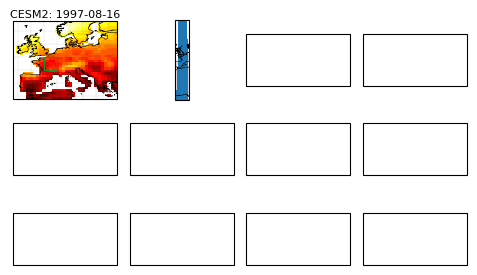

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------------
# Publication figure settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.5

FONT_SIZE = 8

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE - 1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------------------------------------------------
# Select event
# ---------------------------------------------------------------------
date = 2808 #3000 #=year 2036
year = 1997
hw_month = "08"
hw_day = "16"

date_text = f"{year}-{hw_month}-{hw_day}"

print("Date:", ds_test_eth_fact.isel(time=date).time.values)

# ---------------------------------------------------------------------
# Compute ensemble means
# ---------------------------------------------------------------------
fact_dae_mean_h = fact_dae_mean #.TREFHT
cf_dae_mean_h = cf_dae_mean #.TREFHT

# ---------------------------------------------------------------------
# Find coldest / warmest members
# ---------------------------------------------------------------------
imin_fact = dae_eth_ens_spatial_mean.isel(time=date).argmin(dim="ensemble_member")
imax_fact = dae_eth_ens_spatial_mean.isel(time=date).argmax(dim="ensemble_member")
imin_cf = dae_eth_ens_spatial_mean_cf.isel(time=date).argmin(dim="ensemble_member")
imax_cf = dae_eth_ens_spatial_mean_cf.isel(time=date).argmax(dim="ensemble_member")

# ---------------------------------------------------------------------
# Absolute fields — needed both for the diff-to-truth rows (1-2)
# and for the factual-minus-counterfactual row (3)
# ---------------------------------------------------------------------
fact_col0 = ds_test_eth_fact.isel(time=date)
cf_col0 = ds_test_eth_cf.isel(time=date)

fact_fields = [
    fact_col0,
    fact_dae_mean_h.isel(time=date),
    dae_eth_fact.TREFHT.isel(ensemble_member=imin_fact, time=date),
    dae_eth_fact.TREFHT.isel(ensemble_member=imax_fact, time=date),
]

cf_fields = [
    cf_col0,
    cf_dae_mean_h.isel(time=date),
    dae_eth_cf.TREFHT.isel(ensemble_member=imin_cf, time=date),
    dae_eth_cf.TREFHT.isel(ensemble_member=imax_cf, time=date),
]

# Row 1: factual — column 0 stays absolute, columns 1-3 become diffs to column 0
fact_diffs = [f - fact_col0.values for f in fact_fields[1:]]

# Row 2: counterfactual — same treatment
cf_diffs = [f - cf_col0.values for f in cf_fields[1:]]

# Row 3: factual minus counterfactual, panel-by-panel (uses the absolute fields)
diff_fields = [f - c.values for f, c in zip(fact_fields, cf_fields)]

fields = [fact_col0, *fact_diffs, cf_col0, *cf_diffs, *diff_fields]
is_diff_col = [False, True, True, True,   # row 1
               False, True, True, True,   # row 2
               True, True, True, True]    # row 3 — all diff-scale

titles = [
    f"CESM2: {date_text}",
    "DAE median",
    "DAE coldest",
    "DAE warmest",
    "", "", "", "",
    "", "", "", "",
]

# indices (in the flat 12-panel layout) to leave empty: row 3, cols 2 and 3
skip_indices = {10, 11}

# ---------------------------------------------------------------------
# Plot settings — absolute (rows 1-2, column 0)
# ---------------------------------------------------------------------
vmin = 10
vmax = 36
levels = np.linspace(vmin, vmax, 27)
cbar_ticks = np.arange(10, 37, 5)
cmap = "hot_r"

# Plot settings — differences (rows 1-2 cols 1-3, and all of row 3)
diff_vmin, diff_vmax = -5, 5
diff_levels = np.linspace(diff_vmin, diff_vmax, 21)
diff_cbar_ticks = np.arange(diff_vmin, diff_vmax + 1, 2)
diff_cmap = "RdBu_r"

# France domain box
box_lat_min, box_lat_max = 45, 50
box_lon_min, box_lon_max = 0, 5
box_lons = [box_lon_min, box_lon_max, box_lon_max, box_lon_min, box_lon_min]
box_lats = [box_lat_min, box_lat_min, box_lat_max, box_lat_max, box_lat_min]

# ---------------------------------------------------------------------
# Create figure with GridSpec: cbar-slot | col0 | col1 | col2 | col3, x3 rows
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

gs = GridSpec(
    3, 5,
    width_ratios=[0.06, 1, 1, 1, 1],
    wspace=0.15,
    hspace=0.12,
    left=0.10,
    right=0.885,
    bottom=0.07,
    top=0.93,
    figure=fig,
)

axes = []
col_map = {0: 1, 1: 2, 2: 3, 3: 4}  # panel column -> gridspec column (skipping cbar slot at 0)

for row in range(3):
    for col in range(4):
        ax = fig.add_subplot(gs[row, col_map[col]], projection=ccrs.PlateCarree())
        axes.append(ax)

# ---------------------------------------------------------------------
# Plot panels
# ---------------------------------------------------------------------
pc_main = None
pc_diff = None

for i, (ax, field, title, diff_col) in enumerate(zip(axes, fields, titles, is_diff_col)):

    if i in skip_indices:
        ax.set_visible(False)  # leave this panel empty
        continue

    ax.add_feature(cfeature.LAND, facecolor="0.88", edgecolor="none", zorder=0)
    ax.coastlines(resolution="50m", linewidth=0.4, zorder=3)

    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=diff_cmap if diff_col else cmap,
        levels=diff_levels if diff_col else levels,
        vmin=diff_vmin if diff_col else vmin,
        vmax=diff_vmax if diff_col else vmax,
        add_colorbar=False,
        rasterized=True,
        zorder=2,
    )

    if diff_col:
        pc_diff = pc
    else:
        pc_main = pc

    ax.plot(box_lons, box_lats, transform=ccrs.PlateCarree(),
            color="forestgreen", linewidth=0.8, zorder=4)

    ax.gridlines(draw_labels=False, linewidth=0.25, color="0.5",
                 alpha=0.5, linestyle="--", zorder=1)

    ax.set_title(title, pad=2)

# ---------------------------------------------------------------------
# Row labels
# ---------------------------------------------------------------------
axes[0].text(-0.05, 0.5, "Factual", transform=axes[0].transAxes,
             rotation=90, va="center", ha="center", color="tab:red")

axes[4].text(-0.05, 0.5, "Counterfactual", transform=axes[4].transAxes,
             rotation=90, va="center", ha="center", color="tab:blue")

axes[8].text(-0.125, 0.5, "Factual $-$\nCounterfactual", transform=axes[8].transAxes,
             rotation=90, va="center", ha="center", color="0.2")

# ---------------------------------------------------------------------
# Panel label
# ---------------------------------------------------------------------
axes[0].text(-0.12, 1.04, "c)", transform=axes[0].transAxes, va="bottom", ha="left")

# ---------------------------------------------------------------------
# Colorbars
# ---------------------------------------------------------------------
pos_main_slot = gs[0:2, 0].get_position(fig)

shrink_factor = 0.8
full_height = pos_main_slot.y1 - pos_main_slot.y0
new_height = full_height * shrink_factor
y_offset = (full_height - new_height) / 2

cax_main = fig.add_axes([
    pos_main_slot.x0,
    pos_main_slot.y0 + y_offset,
    pos_main_slot.x1 - pos_main_slot.x0,
    new_height,
])

cbar_main = fig.colorbar(
    pc_main, cax=cax_main, orientation="vertical",
    boundaries=levels, ticks=cbar_ticks, spacing="proportional",
)
cbar_main.set_label(r"$\mathrm{T}_{5d}$ [$^\circ$C]", labelpad=3)
cbar_main.ax.tick_params(labelsize=FONT_SIZE - 1, width=0.4, length=2, pad=1)
cbar_main.outline.set_linewidth(0.4)
cax_main.yaxis.set_ticks_position("left")
cax_main.yaxis.set_label_position("left")

cax_diff = fig.add_axes([0.895, 0.09, 0.012, 0.84])
cbar_diff = fig.colorbar(
    pc_diff, cax=cax_diff, orientation="vertical",
    boundaries=diff_levels, ticks=diff_cbar_ticks, spacing="proportional",
)
cbar_diff.set_label(r"$\Delta \mathrm{T}_{5d}$ [$^\circ$C]", labelpad=3)
cbar_diff.ax.tick_params(labelsize=FONT_SIZE - 1, width=0.4, length=2, pad=1)
cbar_diff.outline.set_linewidth(0.4)
# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
#fig.savefig(f"/home/sc.uni-leipzig.de/fl53wumy/llaae_new/TowardsDistributionalAutoencoderClimateCounterfactuals/figures/model_6037/ETH_1300_test_hw_Figure04c_updated.pdf", bbox_inches="tight")

plt.show()

In [14]:
# backup
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------------------------------------------------------------
# Domain
# ---------------------------------------------------------------------


# FRANCE
ger_lat_min = 45
ger_lat_max = 50
ger_lon_min= 0
ger_lon_max= 5


# ---------------------------------------------------------------------
# Publication figure settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.42

FONT_SIZE = 8

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE - 1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------------------------------------------------
# Select event
# ---------------------------------------------------------------------
date = 2803 #3000 #=year 2036
year = 1997
hw_month = "07"
hw_day = "22"



# date = 1506  # 2019-06-27
# year = 2019
# hw_month = "06"
# hw_day = "27"

date_text = f"{year}-{hw_month}-{hw_day}"

print("Date:", ds_test_eth_fact.isel(time=date).time.values)

# ---------------------------------------------------------------------
# Compute ensemble means
# ---------------------------------------------------------------------
fact_dae_mean = dae_eth_fact.TREFHT.mean(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.TREFHT.mean(dim="ensemble_member")

# ---------------------------------------------------------------------
# Find coldest / warmest members
# ---------------------------------------------------------------------
imin_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmin(dim="ensemble_member")
)

imax_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

imin_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmin(dim="ensemble_member")
)

imax_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

# ---------------------------------------------------------------------
# Fields
# ---------------------------------------------------------------------
fields = [
    # factual
    ds_test_eth_fact.isel(time=date),
    fact_dae_mean.isel(time=date),
    dae_eth_fact.TREFHT.isel(ensemble_member=imin_fact, time=date),
    dae_eth_fact.TREFHT.isel(ensemble_member=imax_fact, time=date),

    # counterfactual
    ds_test_eth_cf.isel(time=date),
    cf_dae_mean.isel(time=date),
    dae_eth_cf.TREFHT.isel(ensemble_member=imin_cf, time=date),
    dae_eth_cf.TREFHT.isel(ensemble_member=imax_cf, time=date),
]

titles = [
    f"CESM2: {date_text}",
    "DAE mean",
    "DAE coldest",
    "DAE warmest",
    "",
    "",
    "",
    "",
]

# ---------------------------------------------------------------------
# Plot settings
# ---------------------------------------------------------------------
vmin = 10
vmax = 36

# finer contour levels
levels = np.linspace(vmin, vmax, 27)

# sparse colorbar ticks
cbar_ticks = np.arange(10, 37, 5)

cmap = "hot_r"

# France domain box
box_lat_min = 45
box_lat_max = 50
box_lon_min = 0
box_lon_max = 5

box_lons = [
    box_lon_min,
    box_lon_max,
    box_lon_max,
    box_lon_min,
    box_lon_min,
]

box_lats = [
    box_lat_min,
    box_lat_min,
    box_lat_max,
    box_lat_max,
    box_lat_min,
]

# ---------------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    4,
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=False,
)

axes = axes.ravel()

# ---------------------------------------------------------------------
# Plot panels
# ---------------------------------------------------------------------
for i, (ax, field, title) in enumerate(zip(axes, fields, titles)):

    # background
    ax.add_feature(
        cfeature.LAND,
        facecolor="0.88",
        edgecolor="none",
        zorder=0,
    )

    ax.coastlines(
        resolution="50m",
        linewidth=0.4,
        zorder=3,
    )

    # temperature field
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        levels=levels,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        rasterized=True,
        zorder=2,
    )

    # domain box
    if i == 0:
        ax.plot(
            box_lons,
            box_lats,
            transform=ccrs.PlateCarree(),
            color="forestgreen",
            linewidth=0.8,
            zorder=4,
        )

    # subtle gridlines
    ax.gridlines(
        draw_labels=False,
        linewidth=0.25,
        color="0.5",
        alpha=0.5,
        linestyle="--",
        zorder=1,
    )

    ax.set_title(title, pad=2)

# ---------------------------------------------------------------------
# Row labels
# ---------------------------------------------------------------------
axes[0].text(
    -0.13,
    0.5,
    "Factual",
    transform=axes[0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    color="tab:red",
)

axes[4].text(
    -0.13,
    0.5,
    "Counterfactual",
    transform=axes[4].transAxes,
    rotation=90,
    va="center",
    ha="center",
    color="tab:blue",
)

# ---------------------------------------------------------------------
# Panel label
# ---------------------------------------------------------------------
axes[0].text(
    -0.12,
    1.04,
    "c)",
    transform=axes[0].transAxes,
    va="bottom",
    ha="left",
)

# ---------------------------------------------------------------------
# Layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.055,
    right=0.885,
    bottom=0.10,
    top=0.90,
    wspace=0.015,
    hspace=0.04,
)

# ---------------------------------------------------------------------
# Discrete colorbar
# ---------------------------------------------------------------------
cax = fig.add_axes([0.895, 0.18, 0.012, 0.60])

cbar = fig.colorbar(
    pc,
    cax=cax,
    orientation="vertical",
    boundaries=levels,
    ticks=cbar_ticks,
    spacing="proportional",
)

cbar.set_label(
    r"$\mathrm{T}_{5d}$ [$^\circ$C]",
    labelpad=3,
)

cbar.ax.tick_params(
    labelsize=FONT_SIZE - 1,
    width=0.4,
    length=2,
    pad=1,
)

cbar.outline.set_linewidth(0.4)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
#fig.savefig(f"Figure05/dpa_field_sample_FR_{date_text}.pdf", bbox_inches="tight")

# fig.savefig(
#     f"dpa_field_sample_FR_{date_text}.png",
#     bbox_inches="tight",
#     dpi=600,
# )

plt.show()

Date: 1997-07-22 00:00:00


TypeError: cannot use a Dataset as an indexer

## Time Series

<xarray.DataArray 'TREFHT' (time: 1729)> Size: 14kB
array([12.52316221, 16.69561772, 14.26134049, ..., 22.24754309,
       19.24404983, 21.35914987], shape=(1729,))
Coordinates:
  * time     (time) object 14kB 1950-06-02 00:00:00 ... 2040-08-31 00:00:00
DatetimeIndex(['1997-08-16'], dtype='datetime64[ns]', freq=None)


/tmp/ipykernel_1693494/1318667522.py:319: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_1693494/1318667522.py:319: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_1693494/1318667522.py:320: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword

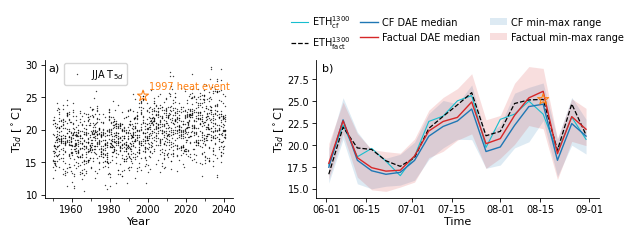

DatetimeIndex(['1997-08-16'], dtype='datetime64[ns]', freq=None)


In [15]:
# backup
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

date_text="1997-08-16"

# ---------------------------------------------------------------------
# Publication-ready settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.3

FONT_SIZE = 8
SMALL_FONT_SIZE = 7

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": SMALL_FONT_SIZE,
    "ytick.labelsize": SMALL_FONT_SIZE,
    "legend.fontsize": SMALL_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
})

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def weighted_domain_mean(da, lat_min, lat_max, lon_min, lon_max):
    """Latitude-weighted spatial mean over a rectangular domain."""
    da_domain = da.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max),
    )

    weights = np.cos(np.deg2rad(da_domain["lat"]))
    weights = xr.DataArray(
        weights,
        coords={"lat": da_domain["lat"]},
        dims=["lat"],
    )

    return da_domain.weighted(weights).mean(dim=("lat", "lon"))


def prepare_dpa_time_series(
    true_cf,
    dpa_ens_cf,
    dpa_ens_mean_cf,
    true_fact,
    dpa_ens_fact,
    dpa_ens_mean_fact,
    lat_min,
    lat_max,
    lon_min,
    lon_max,
    n_stds=2,
):
    if isinstance(dpa_ens_cf, xr.Dataset):
        dpa_ens_cf = dpa_ens_cf.TREFHT

    if isinstance(dpa_ens_fact, xr.Dataset):
        dpa_ens_fact = dpa_ens_fact.TREFHT

    true_cf_mean = weighted_domain_mean(
        true_cf, lat_min, lat_max, lon_min, lon_max
    )

    true_fact_mean = weighted_domain_mean(
        true_fact, lat_min, lat_max, lon_min, lon_max
    )

    dpa_cf_mean_pre = weighted_domain_mean(
        dpa_ens_cf, lat_min, lat_max, lon_min, lon_max
        #dpa_ens_mean_cf, lat_min, lat_max, lon_min, lon_max
    )

    dpa_fact_mean_pre = weighted_domain_mean(
        dpa_ens_fact, lat_min, lat_max, lon_min, lon_max
        #dpa_ens_mean_fact, lat_min, lat_max, lon_min, lon_max
    )
    
    # compute medians of DAE regional means ensemble 
    dpa_cf_mean = dpa_cf_mean_pre.median(dim="ensemble_member")
    dpa_fact_mean = dpa_fact_mean_pre.median(dim="ensemble_member")

    #dpa_cf_std = weighted_domain_mean(
    #    dpa_ens_cf.std(dim="ensemble_member"),
    #    lat_min,
    #    lat_max,
    #    lon_min,
    #    lon_max,
    #)

    #dpa_fact_std = weighted_domain_mean(
    #    dpa_ens_fact.std(dim="ensemble_member"),
    #    lat_min,
    #    lat_max,
    #    lon_min,
    #    lon_max,
    #)
    # min/max
    fact_lower = dpa_fact_mean_pre.min(dim="ensemble_member")
    fact_upper = dpa_fact_mean_pre.max(dim="ensemble_member")
    
    cf_lower = dpa_cf_mean_pre.min(dim="ensemble_member")
    cf_upper = dpa_cf_mean_pre.max(dim="ensemble_member")

    return {
        "true_cf": true_cf_mean,
        "true_fact": true_fact_mean,
        "dpa_cf_mean": dpa_cf_mean,
        "dpa_fact_mean": dpa_fact_mean,
        "cf_lower": cf_lower,
        "cf_upper": cf_upper,
        "fact_lower": fact_lower,
        "fact_upper": fact_upper,
        "n_stds": n_stds,
    }


def _to_datetime_index(da):
    return da.indexes["time"].to_datetimeindex()


def _select_year(da, plot_year):
    if plot_year is None:
        return da

    try:
        return da.sel(time=str(plot_year))
    except Exception:
        time = _to_datetime_index(da)
        return da.isel(time=time.year == int(plot_year))


def plot_dpa_time_series_on_ax(
    ax,
    ts,
    plot_year=None,
    panel_label="b)",
    ylabel=r"$\mathrm{T}_{5d}$ [$^\circ$C]",
):
    true_cf = _select_year(ts["true_cf"], plot_year)
    true_fact = _select_year(ts["true_fact"], plot_year)
    dpa_cf_mean = _select_year(ts["dpa_cf_mean"], plot_year)
    dpa_fact_mean = _select_year(ts["dpa_fact_mean"], plot_year)
    cf_lower = _select_year(ts["cf_lower"], plot_year)
    cf_upper = _select_year(ts["cf_upper"], plot_year)
    fact_lower = _select_year(ts["fact_lower"], plot_year)
    fact_upper = _select_year(ts["fact_upper"], plot_year)

    time = _to_datetime_index(true_fact)

    ax.plot(
        time,
        true_cf.values,
        color="tab:cyan",
        linewidth=0.8,
        linestyle="-",
        label=r"$\mathrm{ETH^{1300}_{cf}}$",
    )

    ax.plot(
        time,
        true_fact.values,
        color="black",
        linewidth=0.9,
        linestyle="--",
        label=r"$\mathrm{ETH^{1300}_{fact}}$",
    )
    

    ax.plot(
        time,
        dpa_cf_mean.values,
        color="tab:blue",
        linewidth=1.0,
        label="CF DAE median",
    )

    ax.plot(
        time,
        dpa_fact_mean.values,
        color="tab:red",
        linewidth=1.0,
        label="Factual DAE median",
    )

    ax.fill_between(
        time,
        cf_lower.values,
        cf_upper.values,
        color="tab:blue",
        alpha=0.15,
        linewidth=0,
        label="CF min-max range"
        #label=rf"CF DAE $\pm {ts['n_stds']}\sigma$",
    )

    ax.fill_between(
        time,
        fact_lower.values,
        fact_upper.values,
        color="tab:red",
        alpha=0.15,
        linewidth=0,
        label="Factual min-max range"
        #label=rf"Factual DAE $\pm {ts['n_stds']}\sigma$",
    )

    

    time_2003 = true_fact.sel(time=date_text).indexes["time"].to_datetimeindex()
    heatwave_value = true_fact.sel(time=date_text).values

    ax.scatter(
    time_2003,
    heatwave_value,
    marker="*",
    s=70,
    facecolors="none",
    edgecolors="tab:orange",
    linewidth=0.75,
    zorder=5,
    )
    
    ax.set_ylabel(ylabel, labelpad=1)
    ax.set_xlabel("Time", labelpad=1)

    #ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    #ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    # ---------------------------------------------------------------------
    # Date formatting
    # ---------------------------------------------------------------------
    #ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    
    #ax.xaxis.set_minor_locator(mdates.DayLocator(interval=3))

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        pad=2,
    )
    ax.tick_params(
    axis="x",
    which="major",
    #rotation=45,
    )

    ax.text(
        0.02,
        0.98,
        panel_label,
        transform=ax.transAxes,
        fontsize=FONT_SIZE,
        #fontweight="bold",
        ha="left",
        va="top",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=3,
        frameon=False,
        handlelength=1.8,
        columnspacing=1.0,
        handletextpad=0.4,
        borderaxespad=0.2,
    )


# ---------------------------------------------------------------------
# GER domain
# ---------------------------------------------------------------------


# France domain box
box_lat_min = fr_lat_min #45
box_lat_max = fr_lat_max #50
box_lon_min = fr_lon_min #0
box_lon_max = fr_lon_max #5

# ---------------------------------------------------------------------
# Left-panel data: absolute time series
# ---------------------------------------------------------------------
ds_1300 = ds_test_eth_fact.isel(time=slice(0,4769)).sel(time=slice("1950-06-02","2040-08-31")) #subset to 1300 test member

trefht_1300_abs = ut.get_ger_1d_data(
    ds_1300,
    lat_min=ger_lat_min,
    lat_max=ger_lat_max,
    lon_min=ger_lon_min,
    lon_max=ger_lon_max,
)

ds_5day_jja_celsius = trefht_1300_abs
print(ds_5day_jja_celsius)
time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
time_2003 = ds_5day_jja_celsius.sel(time=str(date_text)).indexes["time"].to_datetimeindex()
heatwave_value = ds_5day_jja_celsius.sel(time=date_text).values

print(time_2003)

# ---------------------------------------------------------------------
# Right-panel data: DAE time series
# ---------------------------------------------------------------------
year_tp = year

ts = prepare_dpa_time_series(
    true_cf=ds_test_eth_cf.isel(time=slice(0, 4769)),
    dpa_ens_cf=dae_eth_cf.isel(time=slice(0, 4769)),
    dpa_ens_mean_cf=cf_dae_mean.isel(time=slice(0, 4769)),

    true_fact=ds_test_eth_fact.isel(time=slice(0, 4769)),
    dpa_ens_fact=dae_eth_fact.isel(time=slice(0, 4769)),
    dpa_ens_mean_fact=fact_dae_mean.isel(time=slice(0, 4769)),

    lat_min=ger_lat_min,
    lat_max=ger_lat_max,
    lon_min=ger_lon_min,
    lon_max=ger_lon_max,
    n_stds=2,
)

# ---------------------------------------------------------------------
# Combined figure: 153 mm total width, 1/1 width ratio
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.4, 0.6],
    wspace=0.35,
)

ax_left = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

# =====================================================================
# LEFT PANEL: long-term absolute time series
# =====================================================================
ax_left.scatter(
    time,
    ds_5day_jja_celsius.values,
    marker=".",
    s=4,
    color="black",
    alpha=0.75,
    linewidths=0,
    label=r"JJA $\mathrm{T}_{5d}$",
)

ax_left.scatter(
    time_2003,
    heatwave_value,
    marker="*",
    s=70,
    facecolors="none",
    edgecolors="tab:orange",
    linewidth=0.75,
    zorder=5,
)

ax_left.annotate(
    "1997 heat event",
    xy=(time_2003[0], heatwave_value),
    xytext=(4, 3),
    textcoords="offset points",
    fontsize=SMALL_FONT_SIZE,
    color="tab:orange",
    ha="left",
    va="bottom",
)

ax_left.set_ylabel(r"$\mathrm{T}_{5d}$ [$^\circ$C]", labelpad=1)
ax_left.set_xlabel("Year", labelpad=1)

ax_left.xaxis.set_major_locator(mdates.YearLocator(base=20))
ax_left.xaxis.set_minor_locator(mdates.YearLocator(base=10))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_left.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

ax_left.tick_params(
    axis="x",
    which="minor",
    direction="out",
)

ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)

ax_left.legend(
    loc="upper left",
    bbox_to_anchor=(0.10, 0.98),
    frameon=True,
    handletextpad=0.4,
    borderaxespad=0.0,
    labelspacing=0.35,
    fontsize=SMALL_FONT_SIZE,
)

ax_left.text(
    0.02,
    0.98,
    "a)",
    transform=ax_left.transAxes,
    fontsize=FONT_SIZE,
    #fontweight="bold",
    ha="left",
    va="top",
)

# =====================================================================
# RIGHT PANEL: DAE event time series
# =====================================================================
plot_dpa_time_series_on_ax(
    ax_right,
    ts,
    plot_year=year_tp,
    panel_label="b)",
    ylabel=r"$\mathrm{T}_{5d}$ [$^\circ$C]",
)

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.20,
    top=0.96,
)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
fig.savefig(f"/home/sc.uni-leipzig.de/fl53wumy/llaae_new/TowardsDistributionalAutoencoderClimateCounterfactuals/figures/model_6037/combined_time_series_{year_tp}.pdf",bbox_inches="tight",pad_inches=0.01)

plt.show()

ts
print(time_2003)

<xarray.DataArray 'TREFHT' (time: 1729)> Size: 14kB
array([11.78225549, 16.6670929 , 14.40171926, ..., 22.15815296,
       17.12711909, 19.41892709], shape=(1729,))
Coordinates:
  * time     (time) object 14kB 1950-06-02 00:00:00 ... 2040-08-31 00:00:00
DatetimeIndex(['1997-07-22'], dtype='datetime64[ns]', freq=None)


/tmp/ipykernel_1875257/2988530303.py:300: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_1875257/2988530303.py:300: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_1875257/2988530303.py:306: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword

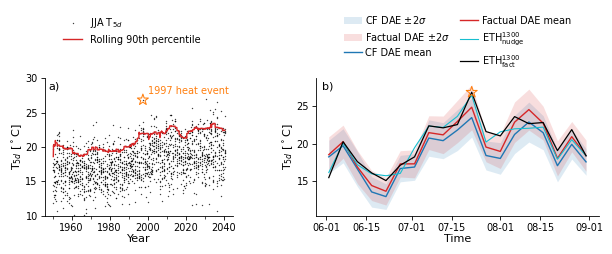

{'true_cf': <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
 array([10.167785  , 15.08507026, 16.78362125, ..., 17.8611483 ,
        17.11267186, 15.89463146], shape=(4769,))
 Coordinates:
   * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00,
 'true_fact': <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
 array([10.4704105 , 14.32043687, 16.33472682, ..., 23.855574  ,
        19.15650261, 24.11819587], shape=(4769,))
 Coordinates:
   * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00,
 'dpa_cf_mean': <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
 array([ 9.20689168, 13.49772585, 14.87312976, ..., 17.6000715 ,
        13.58687247, 15.9659674 ], shape=(4769,))
 Coordinates:
   * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00,
 'dpa_fact_mean': <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
 array([ 9.27396122, 13.56384819, 14.84460832, ..., 25.15688249,
        19.01894828, 23.17909799], shape=(4769

In [15]:
# including percentiles
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

date_text = "1997-07-22"

# ---------------------------------------------------------------------
# Publication-ready settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.3

FONT_SIZE = 8
SMALL_FONT_SIZE = 7

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": SMALL_FONT_SIZE,
    "ytick.labelsize": SMALL_FONT_SIZE,
    "legend.fontsize": SMALL_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
})

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def weighted_domain_mean(da, lat_min, lat_max, lon_min, lon_max):
    """Latitude-weighted spatial mean over a rectangular domain."""
    da_domain = da.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max),
    )

    weights = np.cos(np.deg2rad(da_domain["lat"]))
    weights = xr.DataArray(
        weights,
        coords={"lat": da_domain["lat"]},
        dims=["lat"],
    )

    return da_domain.weighted(weights).mean(dim=("lat", "lon"))


def prepare_dpa_time_series(
    true_cf,
    dpa_ens_cf,
    dpa_ens_mean_cf,
    true_fact,
    dpa_ens_fact,
    dpa_ens_mean_fact,
    lat_min,
    lat_max,
    lon_min,
    lon_max,
    n_stds=2,
):
    if isinstance(dpa_ens_cf, xr.Dataset):
        dpa_ens_cf = dpa_ens_cf.TREFHT

    if isinstance(dpa_ens_fact, xr.Dataset):
        dpa_ens_fact = dpa_ens_fact.TREFHT

    true_cf_mean = weighted_domain_mean(
        true_cf, lat_min, lat_max, lon_min, lon_max
    )

    true_fact_mean = weighted_domain_mean(
        true_fact, lat_min, lat_max, lon_min, lon_max
    )

    dpa_cf_mean = weighted_domain_mean(
        dpa_ens_mean_cf, lat_min, lat_max, lon_min, lon_max
    )

    dpa_fact_mean = weighted_domain_mean(
        dpa_ens_mean_fact, lat_min, lat_max, lon_min, lon_max
    )

    dpa_cf_std = weighted_domain_mean(
        dpa_ens_cf.std(dim="ensemble_member"),
        lat_min,
        lat_max,
        lon_min,
        lon_max,
    )

    dpa_fact_std = weighted_domain_mean(
        dpa_ens_fact.std(dim="ensemble_member"),
        lat_min,
        lat_max,
        lon_min,
        lon_max,
    )

    return {
        "true_cf": true_cf_mean,
        "true_fact": true_fact_mean,
        "dpa_cf_mean": dpa_cf_mean,
        "dpa_fact_mean": dpa_fact_mean,
        "cf_lower": dpa_cf_mean - n_stds * dpa_cf_std,
        "cf_upper": dpa_cf_mean + n_stds * dpa_cf_std,
        "fact_lower": dpa_fact_mean - n_stds * dpa_fact_std,
        "fact_upper": dpa_fact_mean + n_stds * dpa_fact_std,
        "n_stds": n_stds,
    }


def _to_datetime_index(da):
    return da.indexes["time"].to_datetimeindex()


def _select_year(da, plot_year):
    if plot_year is None:
        return da

    try:
        return da.sel(time=str(plot_year))
    except Exception:
        time = _to_datetime_index(da)
        return da.isel(time=time.year == int(plot_year))


def plot_dpa_time_series_on_ax(
    ax,
    ts,
    plot_year=None,
    panel_label="b)",
    ylabel=r"$\mathrm{T}_{5d}$ [$^\circ$C]",
):
    true_cf = _select_year(ts["true_cf"], plot_year)
    true_fact = _select_year(ts["true_fact"], plot_year)
    dpa_cf_mean = _select_year(ts["dpa_cf_mean"], plot_year)
    dpa_fact_mean = _select_year(ts["dpa_fact_mean"], plot_year)
    cf_lower = _select_year(ts["cf_lower"], plot_year)
    cf_upper = _select_year(ts["cf_upper"], plot_year)
    fact_lower = _select_year(ts["fact_lower"], plot_year)
    fact_upper = _select_year(ts["fact_upper"], plot_year)

    time = _to_datetime_index(true_fact)

    ax.fill_between(
        time,
        cf_lower.values,
        cf_upper.values,
        color="tab:blue",
        alpha=0.15,
        linewidth=0,
        label=rf"CF DAE $\pm {ts['n_stds']}\sigma$",
    )

    ax.fill_between(
        time,
        fact_lower.values,
        fact_upper.values,
        color="tab:red",
        alpha=0.15,
        linewidth=0,
        label=rf"Factual DAE $\pm {ts['n_stds']}\sigma$",
    )

    ax.plot(
        time,
        dpa_cf_mean.values,
        color="tab:blue",
        linewidth=1.0,
        label="CF DAE mean",
    )

    ax.plot(
        time,
        dpa_fact_mean.values,
        color="tab:red",
        linewidth=1.0,
        label="Factual DAE mean",
    )

    ax.plot(
        time,
        true_cf.values,
        color="tab:cyan",
        linewidth=0.8,
        linestyle="-",
        label=r"$\mathrm{ETH^{1300}_{nudge}}$",
    )

    ax.plot(
        time,
        true_fact.values,
        color="black",
        linewidth=0.9,
        linestyle="-",
        label=r"$\mathrm{ETH^{1300}_{fact}}$",
    )

    time_2003 = true_fact.sel(time=date_text).indexes["time"].to_datetimeindex()
    heatwave_value = true_fact.sel(time=date_text).values

    ax.scatter(
        time_2003,
        heatwave_value,
        marker="*",
        s=70,
        facecolors="none",
        edgecolors="tab:orange",
        linewidth=0.75,
        zorder=5,
    )

    ax.set_ylabel(ylabel, labelpad=1)
    ax.set_xlabel("Time", labelpad=1)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        pad=2,
    )

    ax.tick_params(
        axis="x",
        which="major",
    )

    ax.text(
        0.02,
        0.98,
        panel_label,
        transform=ax.transAxes,
        fontsize=FONT_SIZE,
        ha="left",
        va="top",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=False,
        handlelength=1.8,
        columnspacing=1.0,
        handletextpad=0.4,
        borderaxespad=0.2,
    )


# ---------------------------------------------------------------------
# GER domain
# ---------------------------------------------------------------------
# ger_lat_min = 48
# ger_lat_max = 54
# ger_lon_min = 6
# ger_lon_max = 15

# France domain box
box_lat_min = 45
box_lat_max = 50
box_lon_min = 0
box_lon_max = 5

# ---------------------------------------------------------------------
# Left-panel data: absolute time series
# ---------------------------------------------------------------------
ds_1300 = (
    ds_test_eth_fact
    .isel(time=slice(0, 4769))
    .sel(time=slice("1950-06-02", "2040-08-31"))
)

trefht_1300_abs = ut.get_ger_1d_data(
    ds_1300,
    lat_min=ger_lat_min,
    lat_max=ger_lat_max,
    lon_min=ger_lon_min,
    lon_max=ger_lon_max,
)

ds_5day_jja_celsius = trefht_1300_abs

print(ds_5day_jja_celsius)

time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()

time_2003 = (
    ds_5day_jja_celsius
    .sel(time=str(date_text))
    .indexes["time"]
    .to_datetimeindex()
)

heatwave_value = ds_5day_jja_celsius.sel(time=date_text).values

print(time_2003)

# ---------------------------------------------------------------------
# Dynamic rolling 90th percentile threshold
# ---------------------------------------------------------------------
q90_rolling = (
    ds_5day_jja_celsius
    .rolling(time=100, center=True, min_periods=15)
    .construct("window")
    .quantile(0.9, dim="window")
)

# ---------------------------------------------------------------------
# Right-panel data: DAE time series
# ---------------------------------------------------------------------
year_tp = year

ts = prepare_dpa_time_series(
    true_cf=ds_test_eth_cf.isel(time=slice(0, 4769)),
    dpa_ens_cf=dae_eth_cf.isel(time=slice(0, 4769)),
    dpa_ens_mean_cf=cf_dae_mean.isel(time=slice(0, 4769)),

    true_fact=ds_test_eth_fact.isel(time=slice(0, 4769)),
    dpa_ens_fact=dae_eth_fact.isel(time=slice(0, 4769)),
    dpa_ens_mean_fact=fact_dae_mean.isel(time=slice(0, 4769)),

    lat_min=ger_lat_min,
    lat_max=ger_lat_max,
    lon_min=ger_lon_min,
    lon_max=ger_lon_max,
    n_stds=2,
)

# ---------------------------------------------------------------------
# Combined figure: 153 mm total width, 1/1 width ratio
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.4, 0.6],
    wspace=0.35,
)

ax_left = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

# =====================================================================
# LEFT PANEL: long-term absolute time series
# =====================================================================
ax_left.scatter(
    time,
    ds_5day_jja_celsius.values,
    marker=".",
    s=4,
    color="black",
    alpha=0.75,
    linewidths=0,
    label=r"JJA $\mathrm{T}_{5d}$",
)

ax_left.plot(
    time,
    q90_rolling.values,
    color="tab:red",
    linestyle="-",
    linewidth=1.0,
    label=r"Rolling 90th percentile",
)

ax_left.scatter(
    time_2003,
    heatwave_value,
    marker="*",
    s=70,
    facecolors="none",
    edgecolors="tab:orange",
    linewidth=0.75,
    zorder=5,
)

ax_left.annotate(
    "1997 heat event",
    xy=(time_2003[0], heatwave_value),
    xytext=(4, 3),
    textcoords="offset points",
    fontsize=SMALL_FONT_SIZE,
    color="tab:orange",
    ha="left",
    va="bottom",
)

ax_left.set_ylabel(r"$\mathrm{T}_{5d}$ [$^\circ$C]", labelpad=1)
ax_left.set_xlabel("Year", labelpad=1)

ax_left.xaxis.set_major_locator(mdates.YearLocator(base=20))
ax_left.xaxis.set_minor_locator(mdates.YearLocator(base=10))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_left.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

ax_left.tick_params(
    axis="x",
    which="minor",
    direction="out",
)

ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)

#ax_left.legend(
#    loc="upper left",
#    bbox_to_anchor=(0.10, 0.98),
#    frameon=True,
#    handletextpad=0.4,
#    borderaxespad=0.0,
#    labelspacing=0.35,
#    fontsize=SMALL_FONT_SIZE,
#)

ax_left.legend(
        loc="upper left",
        bbox_to_anchor=(0.05, 1.52),
        ncol=1,
        frameon=False,
        #handlelength=1.8,
        #columnspacing=1.0,
        #handletextpad=0.4,
        #borderaxespad=0.2,
    )

ax_left.text(
    0.02,
    0.98,
    "a)",
    transform=ax_left.transAxes,
    fontsize=FONT_SIZE,
    ha="left",
    va="top",
)

ax_left.set_ylim(10,30)

# =====================================================================
# RIGHT PANEL: DAE event time series
# =====================================================================
plot_dpa_time_series_on_ax(
    ax_right,
    ts,
    plot_year=year_tp,
    panel_label="b)",
    ylabel=r"$\mathrm{T}_{5d}$ [$^\circ$C]",
)

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.20,
    top=0.96,
)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
# fig.savefig(
#     f"Figure05/combined_time_series_{year_tp}.pdf",
#     bbox_inches="tight",
#     pad_inches=0.01,
# )

plt.show()

ts

In [25]:
# load large ensemble temperatures


# Factual
#ds_test_le_fact_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht'])
ds_test_le_fact = ds_test_eth_fact #xr.open_dataset(ds_test_le_fact_path)#.TREFHT


# unstack time --> ensemble members

# ds dims: time=476900, lat=32, lon=32
n_ens = 3
n_t = 4769

if ds_test_le_fact.sizes["time"] != n_ens * n_t:
    raise ValueError("time dimension does not match 100 * 4769")

# build ensemble and within-member time-step labels
ens = np.repeat(np.arange(1, n_ens + 1), n_t)
t_in_ens = np.tile(np.arange(n_t), n_ens)

# replace the 1D time index by a MultiIndex, then unstack
ds_test_le_fact_unstacked = (
    ds_test_le_fact.assign_coords(
        time=pd.MultiIndex.from_arrays(
            [ens, t_in_ens],
            names=["member", "time_in_member"]
        )
    )
    .unstack("time")
    .assign_coords(time_in_member=ds_test_le_fact.isel(time=slice(0,4769)).time.values)
)

ds_test_le_fact_unstacked #= ds_test_le_fact 
ds_test_le_fact_unstacked

# factual distribution (2011-2061)
trefht_le_fact_2011_61 = ds_test_le_fact_unstacked.sel(time_in_member=slice("1972", "2022"))

trefht_le_fact_0627 = trefht_le_fact_2011_61.sel(
    time_in_member=(trefht_le_fact_2011_61.time_in_member.dt.month == 8) & (trefht_le_fact_2011_61.time_in_member.dt.day == 16)
)
trefht_le_fact_0627

# counterfactual distribution
trefht_le_fact_1850_1900 = ds_test_le_fact_unstacked.sel(time_in_member=slice("1850", "1900"))

trefht_le_cf_0627 = trefht_le_fact_1850_1900.sel(
    time_in_member=(trefht_le_fact_1850_1900.time_in_member.dt.month == 8) & (trefht_le_fact_1850_1900.time_in_member.dt.day == 16)
)
trefht_le_fact_0627

/tmp/ipykernel_1693494/2081299445.py:24: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'time' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  ds_test_le_fact.assign_coords(


<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, member: 3, time_in_member: 51)> Size: 627kB
array([[[[       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]],

        [[       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]],

        [[       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]],
...
        [[11.803375 ,  7.457611 , 11.799438 , ..., 14.732239 ,
          13.2187805, 13.333466 ],
         [ 9.168915 , 13.212921 , 11.778778 , ..., 15.482697 ,
           9.369873 , 13.2812805],
         [13.188843 , 13.811768 ,  6.8146973, ..., 13.87738  ,
          15.936798 , 12.080688 ]],

        [[11.762939 ,  6.8847046, 11.990356 , ..., 14.808228 ,
          13.001404 , 12.914886 ],
         [ 8.942535 , 13.420715 , 11.678833 , ..., 15.36908  ,
           8.530731 , 13.3272705],
         [12.900757 , 14.102203 ,  6.4257812, ..., 13.856781 ,
          16.150726 , 11.888794 ]],

        [[11.738831 ,  6.519226 , 12.152618 , ..., 14.9826355,
          12.571655 , 12.5877075],
         [ 8.298126 , 13.652039 , 11.653839 , ..., 15.180786 ,
           8.169128 , 13.356567 ],
         [12.307495 , 14.12738  ,  6.0877075, ..., 14.269989 ,
          16.404144 , 11.962616 ]]]], shape=(32, 32, 3, 51), dtype=float32)
Coordinates:
  * member          (member) int64 24B 1 2 3
  * lon             (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
  * lat             (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * time_in_member  (time_in_member) object 408B 1972-08-16 00:00:00 ... 2022...

In [26]:
trefht_le_fact_0627_ger = ut.get_ger_1d_data(trefht_le_fact_0627, 
                                     lat_min = ger_lat_min,
                                     lat_max = ger_lat_max,
                                     lon_min = ger_lon_min,
                                     lon_max = ger_lon_max
                                            )
trefht_le_cf_0627_ger = ut.get_ger_1d_data(trefht_le_cf_0627,
                                     lat_min = ger_lat_min,
                                     lat_max = ger_lat_max,
                                     lon_min = ger_lon_min,
                                     lon_max = ger_lon_max
                                          )

trefht_le_fact_0627_ger
trefht_le_cf_0627_ger
ger_lon_max

5

In [27]:
# define functions
from matplotlib.patches import Patch

#importlib.reload(evaluation)

# ---------------------------------------------------------------------
# Region settings
# ---------------------------------------------------------------------
LAT_MIN, LAT_MAX = ger_lat_min, ger_lat_max
LON_MIN, LON_MAX = ger_lon_min, ger_lon_max

TIME_SLICE = slice(0, 4769)
YEAR = year #1506
DATE = date_text #"2019-06-27"

N_BOOT = 2000
ALPHA = 0.05
TEXT_FS = 8#text_fs  # assumes text_fs already exists in your notebook/script

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def area_weighted_mean(data, lat_min, lat_max, lon_min, lon_max, time=None):
    """Compute cosine-latitude weighted regional mean."""
    regional = data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    if time is not None:
        regional = regional.sel(time=time)

    weights = np.cos(np.deg2rad(regional["lat"]))
    weights_da = xr.DataArray(weights, coords={"lat": regional["lat"]}, dims=["lat"])

    return regional.weighted(weights_da).mean(dim=("lat", "lon"))


def bootstrap_median(values, n_boot=1000, alpha=0.05, rng=None):
    """
    Bootstrap the sample median and return:
    - median of bootstrap medians
    - lower / upper CI of bootstrap medians
    - all bootstrap medians
    """
    values = np.asarray(values).ravel()
    n = values.size

    if rng is None:
        rng = np.random.default_rng()

    boot_medians = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_medians[i] = np.median(sample)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    median_of_medians = np.median(boot_medians)
    ci_low = np.percentile(boot_medians, lower_q)
    ci_high = np.percentile(boot_medians, upper_q)

    return median_of_medians, ci_low, ci_high, boot_medians


def bootstrap_kde_ci(samples, x_grid, n_boot=1000, alpha=0.05, rng=None, bw_method=None):
    """
    Bootstrap pointwise confidence intervals for a Gaussian KDE.

    Returns
    -------
    kde_ref : ndarray
        KDE estimated from the original sample.
    kde_low : ndarray
        Lower pointwise confidence bound.
    kde_high : ndarray
        Upper pointwise confidence bound.
    kde_boot : ndarray
        All bootstrap KDE evaluations.
    """
    samples = np.asarray(samples).ravel()
    n = samples.size

    if rng is None:
        rng = np.random.default_rng()

    kde_boot = np.empty((n_boot, len(x_grid)), dtype=float)

    for i in range(n_boot):
        resample = rng.choice(samples, size=n, replace=True)
        kde = gaussian_kde(resample, bw_method=bw_method)
        kde_boot[i] = kde(x_grid)

    kde_ref = gaussian_kde(samples, bw_method=bw_method)(x_grid)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    kde_low = np.percentile(kde_boot, lower_q, axis=0)
    kde_high = np.percentile(kde_boot, upper_q, axis=0)

    return kde_ref, kde_low, kde_high, kde_boot


# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
cf_truth_all = ds_test_eth_cf.isel(time=TIME_SLICE)
cf_ensemble_all = dae_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_mean_all = cf_dae_mean.isel(time=TIME_SLICE)

fact_truth_all = ds_test_eth_fact.isel(time=TIME_SLICE)
fact_ensemble_all = dae_eth_fact.isel(time=TIME_SLICE)
fact_ensemble_mean_all = fact_dae_mean.isel(time=TIME_SLICE)



# ---------------------------------------------------------------------
# Regional averages on selected date
# ---------------------------------------------------------------------
# Counterfactual
cf_single_ensemble_mean_ger = area_weighted_mean(
    cf_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_ensemble_members_ger = area_weighted_mean(
    cf_ensemble_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_truth_ger = area_weighted_mean(
    cf_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

# Factual
fact_single_ensemble_mean_ger = area_weighted_mean(
    fact_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_ensemble_members_ger = area_weighted_mean(
    fact_ensemble_all.TREFHT, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_truth_ger = area_weighted_mean(
    fact_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

cf_values = cf_ensemble_members_ger.values.ravel()
fact_values = fact_ensemble_members_ger.values.ravel()

# ---------------------------------------------------------------------
# Bootstrap medians
# ---------------------------------------------------------------------
cf_boot_median, cf_median_ci_low, cf_median_ci_high, cf_boot_medians = bootstrap_median(
    cf_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(42),
)

fact_boot_median, fact_median_ci_low, fact_median_ci_high, fact_boot_medians = bootstrap_median(
    fact_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(43),
)

# ---------------------------------------------------------------------
# KDE + bootstrap KDE confidence intervals
# ---------------------------------------------------------------------
bins = np.linspace(
    min(cf_values.min(), fact_values.min()),
    max(cf_values.max(), fact_values.max()),
    30,
)
x = np.linspace(bins[0], bins[-1], 500)

# Optional fixed bandwidth for more stable bootstrap-KDE CIs
cf_bw = gaussian_kde(cf_values).factor
fact_bw = gaussian_kde(fact_values).factor

cf_kde, cf_kde_low, cf_kde_high, _ = bootstrap_kde_ci(
    cf_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(44),
    bw_method=cf_bw,
)

fact_kde, fact_kde_low, fact_kde_high, _ = bootstrap_kde_ci(
    fact_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(45),
    bw_method=fact_bw,
)



from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class HandlerTwoColorPatch(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        r1 = Rectangle(
            (xdescent, ydescent), width/2, height,
            facecolor="tab:blue", alpha=0.15, transform=trans
        )
        r2 = Rectangle(
            (xdescent + width/2, ydescent), width/2, height,
            facecolor="tab:red", alpha=0.15, transform=trans
        )

        return [r1, r2]

# ci_handle = object()


Median intensity change: 1.4458037873213954
k_cf: 31
k_cf: 33
k_cf: 29
k_cf: 30
k_cf: 36
k_cf: 40
k_cf: 31
k_cf: 39
k_cf: 18
k_cf: 38
k_cf: 28
k_cf: 38
k_cf: 30
k_cf: 38
k_cf: 33
k_cf: 38
k_cf: 35
k_cf: 30
k_cf: 27
k_cf: 33
k_cf: 32
k_cf: 33
k_cf: 34
k_cf: 40
k_cf: 34
k_cf: 27
k_cf: 26
k_cf: 27
k_cf: 26
k_cf: 28
k_cf: 32
k_cf: 32
k_cf: 36
k_cf: 34
k_cf: 33
k_cf: 33
k_cf: 31
k_cf: 29
k_cf: 25
k_cf: 27
k_cf: 34
k_cf: 30
k_cf: 29
k_cf: 35
k_cf: 30
k_cf: 30
k_cf: 33
k_cf: 34
k_cf: 33
k_cf: 37
k_cf: 33
k_cf: 29
k_cf: 32
k_cf: 34
k_cf: 29
k_cf: 26
k_cf: 26
k_cf: 32
k_cf: 36
k_cf: 33
k_cf: 28
k_cf: 33
k_cf: 30
k_cf: 24
k_cf: 24
k_cf: 36
k_cf: 29
k_cf: 34
k_cf: 36
k_cf: 40
k_cf: 34
k_cf: 27
k_cf: 29
k_cf: 35
k_cf: 30
k_cf: 26
k_cf: 39
k_cf: 37
k_cf: 33
k_cf: 32
k_cf: 28
k_cf: 27
k_cf: 32
k_cf: 24
k_cf: 36
k_cf: 24
k_cf: 29
k_cf: 29
k_cf: 25
k_cf: 31
k_cf: 29
k_cf: 30
k_cf: 38
k_cf: 36
k_cf: 36
k_cf: 31
k_cf: 38
k_cf: 23
k_cf: 39
k_cf: 28
k_cf: 28
k_cf: 32
k_cf: 35
k_cf: 42
k_cf: 35
k_cf: 33
k_

/tmp/ipykernel_1693494/87198218.py:101: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_obs = float(fact_truth_ger.values)


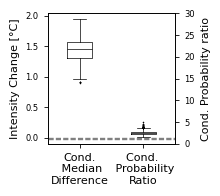

In [28]:
# ---------------------------------------------------------------------
# Bootstrap probability ratios for P(T >= observed)
# and plot as a box plot
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt


def bootstrap_probability_ratio(
    fact_values,
    cf_values,
    threshold,
    n_boot=2000,
    rng=None,
    correction=0.0,
):
    """
    Bootstrap the probability ratio

        PR = P_fact(T >= threshold) / P_cf(T >= threshold)

    using ensemble-member resampling with replacement.

    Parameters
    ----------
    fact_values : array-like
        Factual ensemble values for one day / region.
    cf_values : array-like
        Counterfactual ensemble values for one day / region.
    threshold : float
        Observed threshold temperature.
    n_boot : int
        Number of bootstrap resamples.
    rng : np.random.Generator or None
        Random number generator.
    correction : float
        Continuity correction to avoid division by zero when the
        counterfactual exceedance count is 0. Applied to both numerator
        and denominator counts as:
            p = (k + correction) / (n + 2 * correction)

    Returns
    -------
    pr_boot : ndarray
        Bootstrapped probability ratios.
    p_fact_boot : ndarray
        Bootstrapped factual exceedance probabilities.
    p_cf_boot : ndarray
        Bootstrapped counterfactual exceedance probabilities.
    """
    fact_values = np.asarray(fact_values).ravel()
    cf_values = np.asarray(cf_values).ravel()

    n_fact = fact_values.size
    n_cf = cf_values.size

    if rng is None:
        rng = np.random.default_rng()

    pr_boot = np.empty(n_boot, dtype=float)
    p_fact_boot = np.empty(n_boot, dtype=float)
    p_cf_boot = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        k_fact = np.sum(fact_sample >= threshold)
        k_cf = np.sum(cf_sample >= threshold)
        print("k_cf:", k_cf)

        # Continuity-corrected exceedance probabilities
        p_fact = (k_fact + correction) / (n_fact + 2 * correction)
        p_cf = (k_cf + correction) / (n_cf + 2 * correction)

        p_fact_boot[i] = p_fact
        p_cf_boot[i] = p_cf
        #pr_boot[i] = p_fact / p_cf

        if p_cf != 0:
            pr_boot[i] = p_fact / p_cf
        else:
            pr_boot[i] = 10e8

    return pr_boot, p_fact_boot, p_cf_boot


# ---------------------------------------------------------------------
# Use existing values from your earlier code
# ---------------------------------------------------------------------
# Assumes these already exist:
#   fact_values
#   cf_values
#   fact_truth_ger
#   TEXT_FS

boot_median_diff = fact_boot_medians - cf_boot_medians
print("Median intensity change:", np.percentile(boot_median_diff, 50))


t_obs = float(fact_truth_ger.values)

pr_boot, p_fact_boot, p_cf_boot = bootstrap_probability_ratio(
    fact_values=fact_values,
    cf_values=cf_values,
    threshold=t_obs,
    n_boot=2000,
    rng=np.random.default_rng(123),
    correction=0.5,
)

# Summary stats
pr_median = np.median(pr_boot)
pr_q025 = np.percentile(pr_boot, 2.5)
pr_q25 = np.percentile(pr_boot, 25)
pr_q75 = np.percentile(pr_boot, 75)
pr_q975 = np.percentile(pr_boot, 97.5)

print(f"Observed threshold: {t_obs:.3f} °C")
print(f"Median PR: {pr_median:.3f}")
print(f"IQR: [{pr_q25:.3f}, {pr_q75:.3f}]")
print(f"95% CI: [{pr_q025:.3f}, {pr_q975:.3f}]")

# ---------------------------------------------------------------------
# Box plot
# ---------------------------------------------------------------------


fig, ax1 = plt.subplots(figsize=(2.3, 2.0))

# -------------------------------------------------
# Left axis: median difference
# -------------------------------------------------
lw=0.5
print("Intensity change (median):", boot_median_diff)
box1 = ax1.boxplot(
    boot_median_diff,
    positions=[1],
    widths=0.4,
    vert=True,
    showfliers=True,
    flierprops={
        "marker": "x",
        "markersize": lw,
        "markerfacecolor": "k",
        "markeredgecolor": "k",
        "alpha": 1.0},
    patch_artist=False,
    medianprops={"linewidth": lw, "color": "black"},
    boxprops={"linewidth": lw},
    whiskerprops={"linewidth": lw},
    capprops={"linewidth": lw},
)

ax1.axhline(0, color="gray", linestyle="--", linewidth=1)

ax1.set_ylabel(
    "Intensity Change [°C]", #\n(Factual − Counterfactual)",
    fontsize=8
)

ax1.tick_params(axis="y", labelsize=6)


# -------------------------------------------------
# Right axis: probability ratio
# -------------------------------------------------
ax2 = ax1.twinx()

box2 = ax2.boxplot(
    pr_boot,
    positions=[2],
    widths=0.4,
    vert=True,
    showfliers=True,
    flierprops={
        "marker": "x",
        "markersize": lw,
        "markerfacecolor": "k",
        "markeredgecolor": "k",
        "alpha": 1.0},
    patch_artist=False,
    medianprops={"linewidth": lw, "color": "black"},
    boxprops={"linewidth": lw},
    whiskerprops={"linewidth": lw},
    capprops={"linewidth": lw},
)

ax2.axhline(1, color="gray", linestyle="--", linewidth=1)

ax2.set_ylabel(
    "Cond. Probability ratio", #\n$P_{fact}(T ≥ T_{obs}) / P_{cf}(T ≥ T_{obs})$",
    fontsize=8
)
ax2.set_ylim(0,30)

ax2.tick_params(axis="y", labelsize=6)


# -------------------------------------------------
# X axis formatting
# -------------------------------------------------
ax1.set_xticks([1, 2])
ax1.set_xticklabels(
    ["Cond.\n Median\nDifference", "Cond. \n Probability\nRatio"],
    fontsize=8
)

#ax1.text(0.05, 0.93, "(d)", transform=ax1.transAxes, fontsize=text_fs)

plt.tight_layout()
#plt.savefig("poster_hw2003_FR_boxplot.pdf")
plt.show()

def bootstrap_intensity_shift(fact_values, cf_values, t_obs, n_boot=2000, rng=None):

    fact_values = np.asarray(fact_values)
    cf_values = np.asarray(cf_values)

    n_fact = len(fact_values)
    n_cf = len(cf_values)

    if rng is None:
        rng = np.random.default_rng()

    delta = np.empty(n_boot)

    for i in range(n_boot):

        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        p_fact = np.mean(fact_sample >= t_obs)
        t_cf_equiv = np.quantile(cf_sample, 1 - p_fact)

        delta[i] = t_obs - t_cf_equiv

    return delta


delta_boot = bootstrap_intensity_shift(
    fact_values,
    cf_values,
    t_obs,
    n_boot=2000,
    rng=np.random.default_rng(0)
)



Cond. stds: 1.045465051102601 0.9849307227187359
Factual cond. mean: 25.982769701999068
CF cond. mean: 24.735068377085558
cond. signal: 1.2477013249135105
Factual risk mean: 20.94144074061938
CF risk mean: 20.234317610827137
risk signal: 0.7071231297922438
SNR risk: 0.30765723732601663
SNR storyline: 1.222319096313342
Risk. stds: 2.2958341543311866 2.285932501745174


/tmp/ipykernel_1693494/2486422068.py:341: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(cf_truth_ger.values),
/tmp/ipykernel_1693494/2486422068.py:348: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(fact_truth_ger.values),


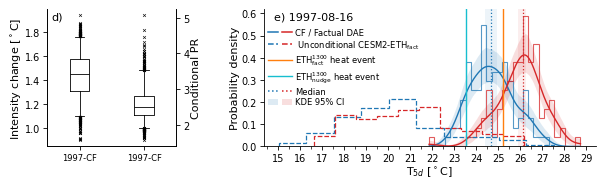

In [29]:
import importlib
importlib.reload(evaluation)
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

# ---------------------------------------------------------------------
# Publication-ready settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4

FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.3 #0.42

FONT_SIZE = 8
SMALL_FONT_SIZE = 7
TINY_FONT_SIZE = 6

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": SMALL_FONT_SIZE,
    "ytick.labelsize": SMALL_FONT_SIZE,
    "legend.fontsize": TINY_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
})

# ---------------------------------------------------------------------
# Figure layout
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.28, 0.72],
    wspace=0.38,
)

# =====================================================================
# LEFT PANEL: BOXPLOTS
# =====================================================================
ax1 = fig.add_subplot(gs[0, 0])

LW = 0.6

common_boxprops = {
    "widths": 0.30,
    "vert": True,
    "showfliers": True,
    "patch_artist": False,
    "flierprops": {
        "marker": "x",
        "markersize": 2,
        "markeredgewidth": 0.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "alpha": 0.9,
    },
    "medianprops": {"linewidth": LW, "color": "black"},
    "boxprops": {"linewidth": LW, "color": "black"},
    "whiskerprops": {"linewidth": LW, "color": "black"},
    "capprops": {"linewidth": LW, "color": "black"},
}

# ---------------------------------------------------------------------
# Left axis: intensity change
# ---------------------------------------------------------------------
ax1.boxplot(
    boot_median_diff,
    positions=[1],
    whis=[2.5, 97.5],
    **common_boxprops,
)

#ax1.axhline(
#    0,
#    color="0.5",
#    linestyle="--",
#    linewidth=0.7,
#    zorder=0,
#)

ax1.set_ylabel(
    r"Intensity change [$^\circ$C]",
    labelpad=0.7,
)

ax1.set_xlim(0.5, 2.5)

ax1.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

# ---------------------------------------------------------------------
# Right y-axis: conditional probability ratio
# ---------------------------------------------------------------------
ax2 = ax1.twinx()

ax2.boxplot(
    pr_boot,
    positions=[2],
    whis=[2.5, 97.5],
    **common_boxprops,
)

#ax2.axhline(
#    1,
#    color="0.5",
#    linestyle="--",
#    linewidth=0.7,
#    zorder=0,
#)

ax2.set_ylabel(
    "Conditional PR",
    labelpad=0.7,
)

#ax2.set_ylim(0, 30)

ax2.tick_params(
    axis="y",
    which="major",
    direction="out",
    pad=2,
)

# ---------------------------------------------------------------------
# X-axis formatting
# ---------------------------------------------------------------------
ax1.set_xticks([1, 2])

ax1.set_xticklabels(
    [
        "1997-CF",
        "1997-CF",
    ],
    fontsize=TINY_FONT_SIZE,
)

# ---------------------------------------------------------------------
# Panel label
# ---------------------------------------------------------------------
ax1.text(
    0.03,
    0.98,
    "d)",
    transform=ax1.transAxes,
    fontsize=FONT_SIZE,
    #fontweight="bold",
    ha="left",
    va="top",
)

# ---------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# =====================================================================
# RIGHT PANEL: DISTRIBUTIONS
# =====================================================================
ax = fig.add_subplot(gs[0, 1])

# ---------------------------------------------------------------------
# Conditional histograms
# ---------------------------------------------------------------------
ax.hist(
    cf_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=0.8,
    alpha=0.75,
    color="tab:blue",
)

ax.hist(
    fact_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=0.8,
    alpha=0.75,
    color="tab:red",
)



std_cond_fact = np.std(fact_values)
std_cond_cf = np.std(cf_values)
print("Cond. stds:", std_cond_fact, std_cond_cf)

print("Factual cond. mean:", np.mean(fact_values))
print("CF cond. mean:", np.mean(cf_values))
print("cond. signal:", np.mean(fact_values) - np.mean(cf_values))
#print("Factual cond. min/max:", np.min(b_risk), np.max(b_risk))
#print("CF cond. min/max:", np.min(a_risk), np.max(a_risk))

# ---------------------------------------------------------------------
# Unconditional histograms
# ---------------------------------------------------------------------
a_risk = trefht_le_cf_0627_ger.values.flatten()
b_risk = trefht_le_fact_0627_ger.values.flatten()

print("Factual risk mean:", np.mean(b_risk))
print("CF risk mean:", np.mean(a_risk))
print("risk signal:", np.mean(b_risk) - np.mean(a_risk))
#print("Factual risk min/max:", np.min(b_risk), np.max(b_risk))
#print("CF risk min/max:", np.min(a_risk), np.max(a_risk))


# signal to noise
snr_risk = evaluation.snr(b_risk, a_risk)
print("SNR risk:", snr_risk)

snr_cond = evaluation.snr(fact_values, cf_values)
print("SNR storyline:", snr_cond)

ax.hist(
    a_risk,
    #bins=bins,
    density=True,
    histtype="step",
    linewidth=0.9,
    linestyle="--",
    color="tab:blue",
)

ax.hist(
    b_risk,
    #bins=bins,
    density=True,
    histtype="step",
    linewidth=0.9,
    linestyle="--",
    color="tab:red",
)

std_risk_fact = np.std(b_risk)
std_risk_cf = np.std(a_risk)
print("Risk. stds:", std_risk_fact, std_risk_cf)

# ---------------------------------------------------------------------
# KDE confidence intervals
# ---------------------------------------------------------------------
ax.fill_between(
    x,
    cf_kde_low,
    cf_kde_high,
    color="tab:blue",
    alpha=0.15,
    linewidth=0,
)

ax.fill_between(
    x,
    fact_kde_low,
    fact_kde_high,
    color="tab:red",
    alpha=0.15,
    linewidth=0,
)

# ---------------------------------------------------------------------
# KDE lines
# ---------------------------------------------------------------------
ax.plot(
    x,
    cf_kde,
    color="tab:blue",
    linewidth=1.0,
)

ax.plot(
    x,
    fact_kde,
    color="tab:red",
    linewidth=1.0,
)

# ---------------------------------------------------------------------
# Median lines
# ---------------------------------------------------------------------
ax.axvline(
    float(cf_boot_median),
    color="tab:blue",
    linestyle=":",
    linewidth=0.9,
)

ax.axvline(
    float(fact_boot_median),
    color="tab:red",
    linestyle=":",
    linewidth=0.9,
)

# ---------------------------------------------------------------------
# Median confidence intervals
# ---------------------------------------------------------------------
ax.axvspan(
    cf_median_ci_low,
    cf_median_ci_high,
    color="tab:blue",
    alpha=0.08,
    linewidth=0,
)

ax.axvspan(
    fact_median_ci_low,
    fact_median_ci_high,
    color="tab:red",
    alpha=0.08,
    linewidth=0,
)

# ---------------------------------------------------------------------
# Truth lines
# ---------------------------------------------------------------------
ax.axvline(
    float(cf_truth_ger.values),
    color="tab:cyan",
    linestyle="-",
    linewidth=1,
)

ax.axvline(
    float(fact_truth_ger.values),
    color="tab:orange",
    linestyle="-",
    linewidth=1,
)

# ---------------------------------------------------------------------
# Labels
# ---------------------------------------------------------------------
ax.set_xlabel(
    r"$\mathrm{T}_{5d}$ [$^\circ$C]",
    labelpad=0.5,
)

ax.set_ylabel(
    "Probability density",
    labelpad=1,
)

# ---------------------------------------------------------------------
# Ticks
# ---------------------------------------------------------------------
ax.xaxis.set_major_locator(MultipleLocator(1.0))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

ax.tick_params(
    axis="x",
    which="minor",
    direction="out",
)

# ---------------------------------------------------------------------
# Panel and date labels
# ---------------------------------------------------------------------
ax.text(
    0.03,
    0.98,
    f"e) {DATE}",
    transform=ax.transAxes,
    fontsize=FONT_SIZE,
    #fontweight="bold",
    ha="left",
    va="top",
)

#ax.text(
#    0.03,
#    0.88,
#    f"{DATE}",
#    transform=ax.transAxes,
#    fontsize=TINY_FONT_SIZE,
#    ha="left",
#    va="top",
#)

# ---------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------------------------------------------------
# Compact combined legend
# ---------------------------------------------------------------------
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

legend_handles = [
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.1),
        Line2D([0], [0], color="tab:red", linewidth=1.1),
    ),
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.1,linestyle="--"),
        Line2D([0], [0], color="tab:red", linewidth=1.1,linestyle="--"),
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="-",
        linewidth=1,
        label=r"$\mathrm{ETH^{1300}_{fact}}$ on 1997-07-22"
    ),
    Line2D(
        [0], [0],
        color="tab:cyan",
        linestyle="-",
        linewidth=1,
        label=r"$\mathrm{ETH^{1300}_{nudge}}$ on 1997-07-22"
    ),
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.1, linestyle=":"),
        Line2D([0], [0], color="tab:red", linewidth=1.1, linestyle=":"),
    ),
    (
        Patch(facecolor="tab:blue",alpha=0.15, edgecolor="none"),
        Patch(facecolor="tab:red", alpha=0.15, edgecolor="none"),
    ),
]

legend_labels = [
    "CF / Factual DAE",
    " Unconditional " + r"$\mathrm{CESM2\text{-}ETH_{fact}}$", 
    r"$\mathrm{ETH^{1300}_{fact}}$ heat event",
    r"$\mathrm{ETH^{1300}_{nudge}}$ heat event",
    "Median",
    "KDE 95% CI",
]

ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="upper left",
    bbox_to_anchor=(0.0, 0.9),
    frameon=False,
    handlelength=2.8,
    handletextpad=0.35,
    borderaxespad=0.15,
    labelspacing=0.22,
    columnspacing=0.55,
    ncol=1,
    fontsize=TINY_FONT_SIZE,
)

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.20,
    top=0.96,
)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
fig.savefig("/home/sc.uni-leipzig.de/fl53wumy/llaae_new/TowardsDistributionalAutoencoderClimateCounterfactuals/figures/model_6037/combined_attribution_figure.pdf",bbox_inches="tight",pad_inches=0.01)

plt.show()

In [24]:
# ---------------------------------------------------------------------
# Print intensity change statistics
# ---------------------------------------------------------------------
print("\n=== Intensity Change ===")

print("CF:")
print("  Median =", np.median(boot_median_diff))
print("  Mean   =", np.mean(boot_median_diff))
print("  95% CI =", np.percentile(boot_median_diff, [2.5, 97.5]))



# ---------------------------------------------------------------------
# Print PR statistics
# ---------------------------------------------------------------------
print("\n=== Conditional Probability Ratio (PR) ===")

print("CF:")
print("  Median =", np.median(pr_boot))
print("  Mean   =", np.mean(pr_boot))
print("  95% CI =", np.percentile(pr_boot, [2.5, 97.5]))




=== Intensity Change ===
CF:
  Median = 1.4458037873213954
  Mean   = 1.44265759981317
  95% CI = [1.09605466 1.75989702]

=== Conditional Probability Ratio (PR) ===
CF:
  Median = 2.5076923076923077
  Mean   = 2.5696165861163145
  95% CI = [1.91754539 3.53061224]


# Misc

In [5]:
weights = np.cos(np.deg2rad(ds_test_eth_fact.lat))
x_eth_fact_reduced_mean = ds_test_eth_fact.TREFHT.weighted(weights).mean(dim=("lat","lon"), skipna=True)
x_eth_fact_reduced_mean_numpy = x_eth_fact_reduced_mean.values

# Counterfactual ERA5 test data
weights = np.cos(np.deg2rad(ds_test_eth_cf.lat))
x_eth_cf_reduced_mean = ds_test_eth_cf.TREFHT.weighted(weights).mean(dim=("lat","lon"), skipna=True)
x_eth_cf_reduced_mean_numpy = x_eth_cf_reduced_mean.values

# DAE ensemble spat means
dpa_eth_fact_ensemble_spat_mean = dae_eth_ens_spatial_mean #dpa_ensemble_fact_raw.TREFHT.mean(dim="lat_x_lon")
dpa_eth_cf_ensemble_spat_mean = dae_eth_ens_spatial_mean_cf #dpa_ensemble_raw_cf.TREFHT.mean(dim="lat_x_lon")

# DAE ensemble mean spat mean
dpa_eth_fact_ensemble_mean_spat_mean = dpa_eth_fact_ensemble_spat_mean.mean(dim="ensemble_member")
dpa_eth_cf_ensemble_mean_spat_mean = dpa_eth_cf_ensemble_spat_mean.mean(dim="ensemble_member")
dpa_eth_cf_ensemble_mean_spat_mean


print("ERA5 test shapes:", x_eth_fact_reduced_mean_numpy.shape, x_eth_cf_reduced_mean_numpy.shape)
test_sets = [x_eth_fact_reduced_mean_numpy, x_eth_cf_reduced_mean_numpy]
dpa_spat_means = [dpa_eth_fact_ensemble_spat_mean, dpa_eth_cf_ensemble_spat_mean]
dae_ensemble_means_spat_means = [dpa_eth_fact_ensemble_mean_spat_mean, dpa_eth_cf_ensemble_mean_spat_mean]

ERA5 test shapes: (14307,) (14307,)


/tmp/ipykernel_3053710/2728318625.py:5: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time = temporal_era5_bias_fact.indexes["time"].to_datetimeindex()
/tmp/ipykernel_3053710/2728318625.py:5: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time = temporal_era5_bias_fact.indexes["time"].to_datetimeindex()
/tmp/ipykernel_3053710/2728318625.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


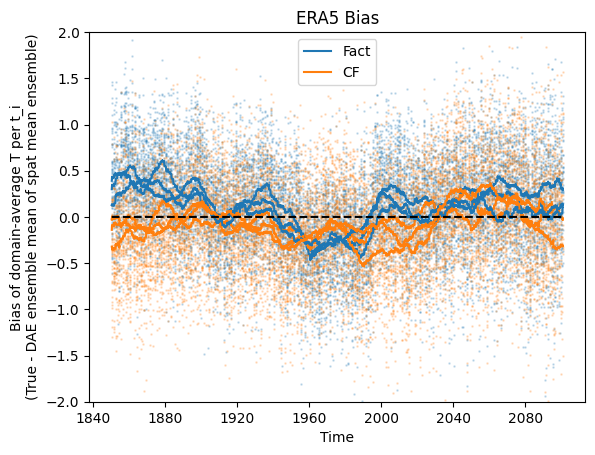

In [8]:
temporal_era5_bias_fact = x_eth_fact_reduced_mean - dpa_eth_fact_ensemble_mean_spat_mean
temporal_era5_bias_cf = x_eth_cf_reduced_mean - dpa_eth_cf_ensemble_mean_spat_mean.assign_coords(time=x_eth_cf_reduced_mean.time)
temporal_era5_bias_cf

time = temporal_era5_bias_fact.indexes["time"].to_datetimeindex()
plt.scatter(time, temporal_era5_bias_fact.values, marker='.', alpha=0.2, s=3)
plt.scatter(time, temporal_era5_bias_cf.values, marker='.', alpha=0.2, s=3)
#temporal_era5_bias_fact.plot.scatter()

def moving_average_edge(x, window):
    kernel = np.ones(window)
    
    # Convolve data
    smoothed = np.convolve(x, kernel, mode='same')
    
    # Convolve ones to count how many valid points contribute at each position
    counts = np.convolve(np.ones_like(x), kernel, mode='same')
    
    return smoothed / counts

window = 200
smooth_era5_bias_fact = moving_average_edge(temporal_era5_bias_fact.values, window)
smooth_era5_bias_cf = moving_average_edge(temporal_era5_bias_cf.values, window)
for i in range(3):
    if i ==2:
        plt.plot(time[i*4769:(i+1)*4769], smooth_era5_bias_fact[i*4769:(i+1)*4769], color="tab:blue", label="Fact")
        plt.plot(time[i*4769:(i+1)*4769], smooth_era5_bias_cf[i*4769:(i+1)*4769], color="tab:orange", label="CF")
        plt.plot(time[i*4769:(i+1)*4769], np.zeros(4769), color='k', linestyle='--')
    else:
        plt.plot(time[i*4769:(i+1)*4769], smooth_era5_bias_fact[i*4769:(i+1)*4769], color="tab:blue")
        plt.plot(time[i*4769:(i+1)*4769], smooth_era5_bias_cf[i*4769:(i+1)*4769], color="tab:orange")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Bias of domain-average T per t_i\n(True - DAE ensemble mean of spat mean ensemble)")
    plt.title("ERA5 Bias")
#plt.savefig("ERA5_2003/time_resolved_bias.pdf")
plt.ylim(-2,2)
plt.show()

In [10]:
era5_dae_thermodynamics

<xarray.DataArray 'TREFHT' (time: 14307)> Size: 57kB
array([4.2570829e-03, 8.7968439e-02, 1.3287613e-01, ..., 5.9120550e+00,
       5.8541431e+00, 6.0112286e+00], shape=(14307,), dtype=float32)
Coordinates:
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

/tmp/ipykernel_3053710/120542269.py:13: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  era5_time = era5_dae_thermodynamics.isel(time=slice(1710,1710+19*84)).indexes["time"].to_datetimeindex()
/tmp/ipykernel_3053710/120542269.py:13: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  era5_time = era5_dae_thermodynamics.isel(time=slice(1710,1710+19*84)).indexes["time"].to_datetimeindex()
/tmp/ipykernel_3053710/120542269.py:17: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeI

<xarray.DataArray 'TREFHT' (time: 14307)> Size: 57kB
array([4.2570829e-03, 8.7968439e-02, 1.3287613e-01, ..., 5.9120550e+00,
       5.8541431e+00, 6.0112286e+00], shape=(14307,), dtype=float32)
Coordinates:
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00


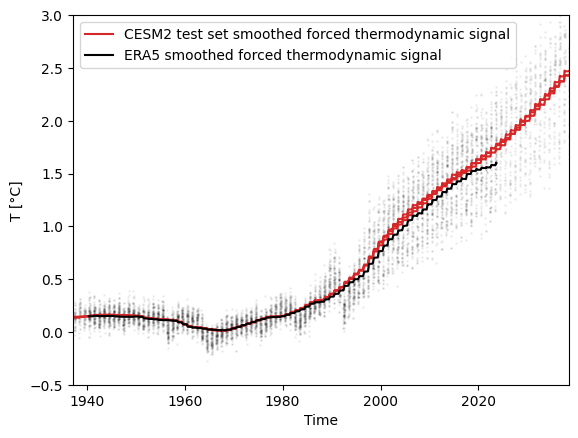

In [60]:
eth_dae_thermodynamics = dpa_eth_fact_ensemble_mean_spat_mean - dpa_eth_cf_ensemble_mean_spat_mean

# smooth thermodynamic signal
smooth_eth_bias_fact = moving_average_edge(era5_dae_thermodynamics.values, window)


smooth_eth_thermodynamics_1300 = moving_average_edge(era5_dae_thermodynamics.values[:4769], window)
smooth_eth_thermodynamics_1400 = moving_average_edge(era5_dae_thermodynamics.values[4769:2*4769], window)
smooth_eth_thermodynamics_1500 = moving_average_edge(era5_dae_thermodynamics.values[4769*2:3*4769], window)

# load ERA5
era5_forced_thermodynamic = np.load("ERA5_thermodynamics_forced.npy")
era5_time = era5_dae_thermodynamics.isel(time=slice(1710,1710+19*84)).indexes["time"].to_datetimeindex()
smooth_era5_bias_fact = moving_average_edge(era5_forced_thermodynamic, window)


time = eth_dae_thermodynamics.indexes["time"].to_datetimeindex()
print(era5_dae_thermodynamics)
plt.scatter(time, eth_dae_thermodynamics.values, marker='.', alpha=0.1, s=3, color="tab:grey")
plt.scatter(era5_time, era5_forced_thermodynamic, marker='.', alpha=0.1, s=3, color="black")
plt.plot(time[:4769], smooth_era5_thermodynamics_1300, color="tab:red")
plt.plot(time[:4769], smooth_era5_thermodynamics_1400, color="tab:red")
plt.plot(time[:4769], smooth_era5_thermodynamics_1500, color="tab:red", label="CESM2 test set smoothed forced thermodynamic signal")
plt.plot(era5_time, smooth_era5_bias_fact, color="black", label="ERA5 smoothed forced thermodynamic signal")

plt.xlabel("Time")
plt.ylabel("T [°C]")
plt.xlim(-12000,25000)
plt.ylim(-0.5,3)
plt.legend()
plt.savefig("general/forced_thermodynamics_comparison.pdf")
#plt.plot(time, smooth_era5_thermodynamics)


In [38]:
era5_dae_thermodynamics.isel(time=slice(1710,1710+19*84))

<xarray.DataArray 'TREFHT' (time: 1596)> Size: 6kB
array([0.12903488, 0.15315413, 0.12514925, ..., 1.8748527 , 2.015304  ,
       1.8336824 ], shape=(1596,), dtype=float32)
Coordinates:
  * time     (time) object 13kB 1940-06-02 00:00:00 ... 2023-08-31 00:00:00

## Maps

In [32]:
date = 3659 #=year 2036
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

Date: 2042-07-27 00:00:00


Date: 2036-06-27 00:00:00


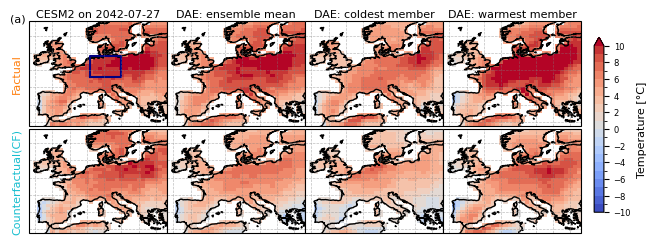

In [33]:
fact_dae_mean = dae_eth_fact.TREFHT.mean(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.TREFHT.mean(dim="ensemble_member")

# Example dataset: ds.TREFHT should exist
date = 3539 #=year 2036
date_text = "2042-07-27"
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

# Factual Fields
# find min and max values of domain average temperature
imin_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
field_1 = fact_dae_mean.isel(time=date)
field_2 = dae_eth_fact.TREFHT.isel(ensemble_member = imin_fact, time=date)
field_3 = dae_eth_fact.TREFHT.isel(ensemble_member = imax_fact, time=date)

# Counterfactual Fields

# find min and max values of domain average temperature
imin_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_cf = ds_test_eth_cf.TREFHT.isel(time=date)
field_1_cf = cf_dae_mean.isel(time=date)
field_2_cf = dae_eth_cf.TREFHT.isel(ensemble_member = imin_cf, time=date)
field_3_cf = dae_eth_cf.TREFHT.isel(ensemble_member = imax_cf, time=date)

# Plot parameters
vmin = -10
vmax = 10
no_levels=21
levels = np.linspace(vmin,vmax,no_levels)
cmap = "coolwarm"

text_fs = 8

# GER domain
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15


# Create figure and subplots
fig, axes = plt.subplots(
    2, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(6.5,2.5)#(14, 6)
)


titles = [f"CESM2 on {date_text}", "DAE: ensemble mean", "DAE: coldest member", "DAE: warmest member", "", "", "", ""]
fields = [field_factual, field_1, field_2, field_3, field_cf, field_1_cf, field_2_cf, field_3_cf]
axes = axes.flatten()

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    

    if ax == axes[0]:
        lons = [ger_lon_min, ger_lon_max, ger_lon_max, ger_lon_min, ger_lon_min]
        lats = [ger_lat_min, ger_lat_min, ger_lat_max, ger_lat_max, ger_lat_min]
        ax.plot(
            lons, lats,
            transform=ccrs.PlateCarree(),
            color="navy",
            linewidth=1.5,
            linestyle="-"
        )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=text_fs, pad=3)


# tighten the grid (no whitespace)
fig.subplots_adjust(left=0.03, right=0.88, bottom=0.06, top=0.92,
                    wspace=0.0, hspace=0.0)

# create a dedicated axis for the colorbar: [left, bottom, width, height]
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])

cbar = fig.colorbar(pc, cax=cax, orientation="vertical")
cbar.set_label("Temperature [°C]", fontsize=text_fs)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=6)

# Set tick positions
cbar.set_ticks(np.linspace(-10,10,11))

axes[0].text(-0.125, 0.5, f'Factual', transform=axes[0].transAxes,
              fontsize=text_fs, rotation=90, color="tab:orange", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[4].text(-0.125, 0.5, f'Counterfactual(CF)', transform=axes[4].transAxes,
              fontsize=text_fs, rotation=90, color="tab:cyan", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[0].text(-0.135,1,"(a)", transform=axes[0].transAxes, fontsize=text_fs)

fig.subplots_adjust(wspace=0.0, hspace=0.0)
#plt.savefig(f"dpa_field_sample_{date_text}.pdf")
plt.show()


## Timeseries

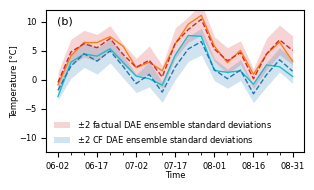

In [34]:
### Factual ###
year_tp = 2042
fig, ax = evaluation.plot_multiple_dpa_time_series(true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens = dae_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens_mean = cf_dae_mean.isel(time=slice(0,4769)),  
                                          true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)),
                                          dpa_ens_fact = dae_eth_fact.isel(time=slice(0,4769)),
                                          dpa_ens_mean_fact = fact_dae_mean.isel(time=slice(0,4769)),
                                          lat_min = ger_lat_min, 
                                          lat_max = ger_lat_max, 
                                          lon_min = ger_lon_min, 
                                          lon_max = ger_lon_max, 
                                          plot_year = [str(year_tp)],
                                          figsize_ts = (3.25,2),
                                          title_fontsize = 6,
                                          title = f"Factual Temperatures Germany {year_tp}", 
                                          climate = "Counterfactual"
                                          )

### add factual time series ###
temp_true_ger_pre = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))

# create weights
# 1) define weights as above
weights_ger = np.cos(np.deg2rad(temp_true_ger_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': temp_true_ger_pre['lat']}, dims=['lat'])

temp_true_ger = temp_true_ger_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))

ax.set_ylabel("Temperature [°C]", fontsize = 6, labelpad=0)
ax.set_xlabel("Time", fontsize=6, labelpad=0)
ax.text(0.04,0.9,"(b)", transform=ax.transAxes, fontsize=text_fs)
plt.tick_params(axis='both', which='major', labelsize=6)
plt.ylim(-12.5,12)
plt.tight_layout()

# title
#plt.title(f"Mean temperatures Germany {year_tp}", fontsize=6)
#plt.legend()
#plt.savefig(f"dpa_time_series_{year_tp}.pdf")
plt.show()

dae_ens_ger_1300: (1, 100)


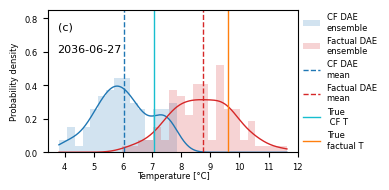

In [6]:
# old

year = "2036"
dae_ens = dae_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_fact = dae_eth_fact.isel(time=slice(0,4769)).sel(time=slice(year,year))

dae_ens_mean = cf_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_mean_fact = fact_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))


lat_min = ger_lat_min 
lat_max = ger_lat_max
lon_min = ger_lon_min 
lon_max = ger_lon_max 
date=date_text

# ensemble mean, germany mean 
dae_ens_mean_ger = dae_ens_mean.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300 = dae_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))
print("dae_ens_ger_1300:", dae_ens_ger_1300.values.T.shape)

# counterfactual truth
true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=date)
cf_truth_ger = true_t.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))




# ensemble mean, germany mean 
dae_ens_mean_ger_fact = dae_ens_mean_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300_fact = dae_ens_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).TREFHT.weighted(w_da_ger).mean(dim=('lat', 'lon'))

# factual truth
true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(time=date)
fact_truth_ger = true_t_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))


# Example data (replace with your own arrays)
a = dae_ens_ger_1300.values.flatten()
b = dae_ens_ger_1300_fact.values.flatten()

# Common bins
bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    30
)

fig, ax = plt.subplots(figsize=(4,2))

# Histograms (normalized)
ax.hist(
    a, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    label="CF DAE\nensemble", color="tab:blue", alpha=0.2
)
ax.hist(
    b, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    label="Factual DAE\nensemble", color="tab:red", alpha=0.2
)

# KDEs
x = np.linspace(bins[0], bins[-1], 500)
kde_a = gaussian_kde(a)
kde_b = gaussian_kde(b)

ax.plot(x, kde_a(x), linewidth=1, color="tab:blue")
ax.plot(x, kde_b(x), linewidth=1, color="tab:red")



# mean values
ax.axvline(
    x=dae_ens_mean_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:blue",
    linestyle="--",
    linewidth=1.0,
    label="CF DAE\nmean"
)

ax.axvline(
    x=dae_ens_mean_ger_fact.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:red",
    linestyle="--",
    linewidth=1.0,
    label="Factual DAE\nmean"
)



ax.axvline(
    x=cf_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:cyan",
    linestyle="-",
    linewidth=1.0,
    label="True\n CF T"
)

ax.axvline(
    x=fact_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:orange",
    linestyle="-",
    linewidth=1.0,
    label="True\nfactual T"
)



# Labels and legend
ax.set_xlabel("Temperature [°C]", fontsize=6, labelpad=0)
ax.set_ylabel("Probability density", fontsize=6)
ax.tick_params(axis="x", labelsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.text(0.04,0.7,f"(c)\n\n{date}", transform=ax.transAxes, fontsize=text_fs)


ax.legend(
    loc="center left",
    bbox_to_anchor=(0.99, 0.5),
    frameon=False,
    fontsize=6
)

fig.subplots_adjust(right=0.75)

#ax.set_xlim(-1,5)
ax.set_ylim(0.0, 0.85)

plt.tight_layout()
#plt.savefig(f"T_distrs_{date_text}.pdf")
plt.show()


## Add risk-based distributions

In [36]:
# load large ensemble temperatures


# Factual
ds_test_le_fact_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht'])
ds_test_le_fact = xr.open_dataset(ds_test_le_fact_path)
ds_test_le_fact

# unstack time --> ensemble members

# ds dims: time=476900, lat=32, lon=32
n_ens = 100
n_t = 4769

if ds_test_le_fact.sizes["time"] != n_ens * n_t:
    raise ValueError("time dimension does not match 100 * 4769")

# build ensemble and within-member time-step labels
ens = np.repeat(np.arange(1, n_ens + 1), n_t)
t_in_ens = np.tile(np.arange(n_t), n_ens)

# replace the 1D time index by a MultiIndex, then unstack
ds_test_le_fact_unstacked = (
    ds_test_le_fact.assign_coords(
        time=pd.MultiIndex.from_arrays(
            [ens, t_in_ens],
            names=["member", "time_in_member"]
        )
    )
    .unstack("time")
    .assign_coords(time_in_member=ds_test_le_fact.isel(time=slice(0,4769)).time.values)
)

# factual distribution (2011-2061)
trefht_le_fact_2011_61 = ds_test_le_fact_unstacked.TREFHT.sel(time_in_member=slice("2017", "2067"))

trefht_le_fact_0627 = trefht_le_fact_2011_61.sel(
    time_in_member=(trefht_le_fact_2011_61.time_in_member.dt.month == 6) & (trefht_le_fact_2011_61.time_in_member.dt.day == 27)
)
trefht_le_fact_0627

# counterfactual distribution
trefht_le_fact_1850_1900 = ds_test_le_fact_unstacked.TREFHT.sel(time_in_member=slice("1850", "1900"))

trefht_le_cf_0627 = trefht_le_fact_1850_1900.sel(
    time_in_member=(trefht_le_fact_1850_1900.time_in_member.dt.month == 6) & (trefht_le_fact_1850_1900.time_in_member.dt.day == 27)
)
trefht_le_cf_0627






/tmp/ipykernel_2754414/4104388086.py:24: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'time' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  ds_test_le_fact.assign_coords(


<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, member: 100, time_in_member: 51)> Size: 21MB
array([[[[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
...
          -0.997406  ,  1.7683105 ],
         [-1.2379761 ,  1.016571  ,  1.8097229 , ...,  0.7380676 ,
           0.6995239 ,  0.31402588],
         [-2.7175903 ,  3.0505981 ,  3.0550232 , ...,  8.026276  ,
          -3.3776245 ,  2.5436707 ]],

        [[-0.73828125, -4.2813416 ,  1.8380737 , ..., -0.37365723,
          -6.226898  ,  1.4903259 ],
         [ 5.494049  , -3.63089   ,  1.924408  , ...,  2.9640198 ,
           4.156189  , -1.9683838 ],
         [ 0.80700684,  7.1707764 ,  1.2277222 , ...,  3.4256897 ,
          -1.3093262 ,  1.1897278 ],
         ...,
         [ 1.2711182 , -0.05834961, -1.7219543 , ..., -2.9446106 ,
          -1.1953735 ,  2.1548767 ],
         [-1.1790771 ,  0.921875  ,  2.2159424 , ...,  1.0066528 ,
           1.003418  ,  0.11166382],
         [-2.84964   ,  3.5766602 ,  2.7470398 , ...,  8.055847  ,
          -3.7910767 ,  3.110199  ]]]],
      shape=(32, 32, 100, 51), dtype=float32)
Coordinates:
  * member          (member) int64 800B 1 2 3 4 5 6 7 ... 94 95 96 97 98 99 100
  * lon             (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
  * lat             (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * time_in_member  (time_in_member) object 408B 1850-06-27 00:00:00 ... 1900...

In [37]:
trefht_le_fact_0627_ger = ut.get_ger_1d_data(trefht_le_fact_0627)
trefht_le_cf_0627_ger = ut.get_ger_1d_data(trefht_le_cf_0627)

trefht_le_fact_0627_ger
trefht_le_cf_0627_ger

<xarray.DataArray 'TREFHT' (member: 100, time_in_member: 51)> Size: 41kB
array([[ 0.5982974 ,  3.58383492, -2.2390304 , ...,  1.31531295,
        -0.51897073,  4.4869289 ],
       [-1.07830706,  3.92573665,  4.36482211, ..., -3.78487479,
        -2.73280664, -0.40980706],
       [-2.58659608, -0.26951288,  4.53340401, ...,  0.88647014,
         1.76728826, -0.27935691],
       ...,
       [ 0.34781491,  1.56559358,  3.02928775, ...,  2.83639512,
        -0.41292424, -0.23337297],
       [ 0.10563499,  0.20844499,  0.05333959, ..., -2.8865407 ,
         1.99450361,  1.61876341],
       [ 2.83381045,  2.42371727,  1.74131216, ...,  2.21019133,
        -1.67363819,  1.03980132]], shape=(100, 51))
Coordinates:
  * member          (member) int64 800B 1 2 3 4 5 6 7 ... 94 95 96 97 98 99 100
  * time_in_member  (time_in_member) object 408B 1850-06-27 00:00:00 ... 1900...

dae_ens_ger_1300: (1, 100)


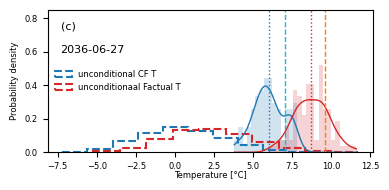

In [9]:
# old

year = "2036"
dae_ens = dae_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_fact = dae_eth_fact.isel(time=slice(0,4769)).sel(time=slice(year,year))

dae_ens_mean = cf_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_mean_fact = fact_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))


lat_min = ger_lat_min 
lat_max = ger_lat_max
lon_min = ger_lon_min 
lon_max = ger_lon_max 
date=date_text

# ensemble mean, germany mean 
dae_ens_mean_ger = dae_ens_mean.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300 = dae_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))
print("dae_ens_ger_1300:", dae_ens_ger_1300.values.T.shape)

# counterfactual truth
true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=date)
cf_truth_ger = true_t.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))




# ensemble mean, germany mean 
dae_ens_mean_ger_fact = dae_ens_mean_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300_fact = dae_ens_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).TREFHT.weighted(w_da_ger).mean(dim=('lat', 'lon'))

# factual truth
true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(time=date)
fact_truth_ger = true_t_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))


# Example data (replace with your own arrays)
a = dae_ens_ger_1300.values.flatten()
b = dae_ens_ger_1300_fact.values.flatten()

# Common bins
bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    30
)

fig, ax = plt.subplots(figsize=(4,2))

# Histograms (normalized)
ax.hist(
    a, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    #label="CF DAE\nensemble",
    color="tab:blue", alpha=0.2
)
ax.hist(
    b, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    #label="Factual DAE\nensemble",
    color="tab:red", alpha=0.2
)


#############################
### risk-based Histograms ###
#############################
a_risk = trefht_le_cf_0627_ger.values.flatten()
b_risk = trefht_le_fact_0627_ger.values.flatten()

ax.hist(
    a_risk,
    density=True,
    histtype="step",
    linewidth=1.5,
    label="unconditional CF T",
    color="tab:blue",
    linestyle="--"
)

ax.hist(
    b_risk,
    density=True,
    histtype="step",
    linewidth=1.5,
    label="unconditionaal Factual T",
    color="tab:red",
    linestyle="--"
)

# KDEs
x = np.linspace(bins[0], bins[-1], 500)
kde_a = gaussian_kde(a)
kde_b = gaussian_kde(b)

ax.plot(x, kde_a(x), linewidth=1, color="tab:blue")
ax.plot(x, kde_b(x), linewidth=1, color="tab:red")



# mean values
ax.axvline(
    x=dae_ens_mean_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:blue",
    linestyle=":",
    linewidth=1.0,
    #label="CF DAE\nmean"
)

ax.axvline(
    x=dae_ens_mean_ger_fact.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:red",
    linestyle=":",
    linewidth=1.0,
    #label="Factual DAE\nmean"
)



ax.axvline(
    x=cf_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:cyan",
    linestyle="--",
    linewidth=1.0,
    #label="True\n CF T"
)

ax.axvline(
    x=fact_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:orange",
    linestyle="--",
    linewidth=1.0,
    #label="True\nfactual T"
)



# Labels and legend
ax.set_xlabel("Temperature [°C]", fontsize=6, labelpad=0)
ax.set_ylabel("Probability density", fontsize=6)
ax.tick_params(axis="x", labelsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.text(0.04,0.7,f"(c)\n\n{date}", transform=ax.transAxes, fontsize=text_fs)


ax.legend(
    loc="center left",
    frameon=False,
    fontsize=6
)

fig.subplots_adjust(right=0.75)

#ax.set_xlim(-1,5)
ax.set_ylim(0.0, 0.85)

plt.tight_layout()
#plt.savefig(f"T_distrs_and_risk_{date_text}.pdf")
plt.show()


dates: [cftime.DatetimeNoLeap(2036, 6, 2, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 7, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 12, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 17, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 22, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 27, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 2, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 7, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 12, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 17, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 22, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 27, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 8, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 8, 6, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 8, 11, 0, 0, 0, 0,

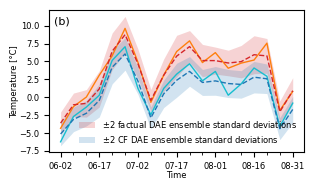

/tmp/ipykernel_2611950/3720660579.py:334: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x=float(cf_truth_ger.values),
/tmp/ipykernel_2611950/3720660579.py:341: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x=float(fact_truth_ger.values),


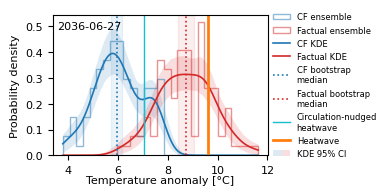

In [10]:
# old
from matplotlib.patches import Patch

#importlib.reload(evaluation)

# ---------------------------------------------------------------------
# Region settings
# ---------------------------------------------------------------------
LAT_MIN, LAT_MAX = 48, 54
LON_MIN, LON_MAX = 6, 15

TIME_SLICE = slice(0, 4769)
YEAR = 2036
DATE = "2036-06-27"

N_BOOT = 2000
ALPHA = 0.05
TEXT_FS = text_fs  # assumes text_fs already exists in your notebook/script

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def area_weighted_mean(data, lat_min, lat_max, lon_min, lon_max, time=None):
    """Compute cosine-latitude weighted regional mean."""
    regional = data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    if time is not None:
        regional = regional.sel(time=time)

    weights = np.cos(np.deg2rad(regional["lat"]))
    weights_da = xr.DataArray(weights, coords={"lat": regional["lat"]}, dims=["lat"])

    return regional.weighted(weights_da).mean(dim=("lat", "lon"))


def bootstrap_median(values, n_boot=1000, alpha=0.05, rng=None):
    """
    Bootstrap the sample median and return:
    - median of bootstrap medians
    - lower / upper CI of bootstrap medians
    - all bootstrap medians
    """
    values = np.asarray(values).ravel()
    n = values.size

    if rng is None:
        rng = np.random.default_rng()

    boot_medians = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_medians[i] = np.median(sample)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    median_of_medians = np.median(boot_medians)
    ci_low = np.percentile(boot_medians, lower_q)
    ci_high = np.percentile(boot_medians, upper_q)

    return median_of_medians, ci_low, ci_high, boot_medians


def bootstrap_kde_ci(samples, x_grid, n_boot=1000, alpha=0.05, rng=None, bw_method=None):
    """
    Bootstrap pointwise confidence intervals for a Gaussian KDE.

    Returns
    -------
    kde_ref : ndarray
        KDE estimated from the original sample.
    kde_low : ndarray
        Lower pointwise confidence bound.
    kde_high : ndarray
        Upper pointwise confidence bound.
    kde_boot : ndarray
        All bootstrap KDE evaluations.
    """
    samples = np.asarray(samples).ravel()
    n = samples.size

    if rng is None:
        rng = np.random.default_rng()

    kde_boot = np.empty((n_boot, len(x_grid)), dtype=float)

    for i in range(n_boot):
        resample = rng.choice(samples, size=n, replace=True)
        kde = gaussian_kde(resample, bw_method=bw_method)
        kde_boot[i] = kde(x_grid)

    kde_ref = gaussian_kde(samples, bw_method=bw_method)(x_grid)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    kde_low = np.percentile(kde_boot, lower_q, axis=0)
    kde_high = np.percentile(kde_boot, upper_q, axis=0)

    return kde_ref, kde_low, kde_high, kde_boot


# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
cf_truth_all = ds_test_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_all = dae_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_mean_all = cf_dae_mean.isel(time=TIME_SLICE)

fact_truth_all = ds_test_eth_fact.isel(time=TIME_SLICE).TREFHT
fact_ensemble_all = dae_eth_fact.isel(time=TIME_SLICE)
fact_ensemble_mean_all = fact_dae_mean.isel(time=TIME_SLICE)

print("dates:", cf_truth_all.sel(time=str(YEAR)).time.values)

# ---------------------------------------------------------------------
# Time series panel
# ---------------------------------------------------------------------
fig, ax = evaluation.plot_multiple_dpa_time_series(
    true_t=cf_truth_all,
    dpa_ens=cf_ensemble_all,
    dpa_ens_mean=cf_ensemble_mean_all,
    true_t_fact=fact_truth_all,
    dpa_ens_fact=fact_ensemble_all,
    dpa_ens_mean_fact=fact_ensemble_mean_all,
    lat_min=LAT_MIN,
    lat_max=LAT_MAX,
    lon_min=LON_MIN,
    lon_max=LON_MAX,
    plot_year=[str(YEAR)],
    figsize_ts=(3.25,2), #(3.25, 2),
    title_fontsize=6,
    title=f"Factual Temperatures Germany {YEAR}",
    climate="Counterfactual",
)

ax.set_ylabel("Temperature [°C]", fontsize=6, labelpad=0)
ax.set_xlabel("Time", fontsize=6, labelpad=0)
ax.text(0.02, 0.9, "(b)", transform=ax.transAxes, fontsize=TEXT_FS)
ax.tick_params(axis="both", which="major", labelsize=6)

plt.tight_layout()
#plt.savefig("hw_timeseries.pdf")

plt.show()

# ---------------------------------------------------------------------
# Regional averages on selected date
# ---------------------------------------------------------------------
# Counterfactual
cf_single_ensemble_mean_ger = area_weighted_mean(
    cf_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_ensemble_members_ger = area_weighted_mean(
    cf_ensemble_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_truth_ger = area_weighted_mean(
    cf_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

# Factual
fact_single_ensemble_mean_ger = area_weighted_mean(
    fact_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_ensemble_members_ger = area_weighted_mean(
    fact_ensemble_all.TREFHT, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_truth_ger = area_weighted_mean(
    fact_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

cf_values = cf_ensemble_members_ger.values.ravel()
fact_values = fact_ensemble_members_ger.values.ravel()

# ---------------------------------------------------------------------
# Bootstrap medians
# ---------------------------------------------------------------------
cf_boot_median, cf_median_ci_low, cf_median_ci_high, cf_boot_medians = bootstrap_median(
    cf_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(42),
)

fact_boot_median, fact_median_ci_low, fact_median_ci_high, fact_boot_medians = bootstrap_median(
    fact_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(43),
)

# ---------------------------------------------------------------------
# KDE + bootstrap KDE confidence intervals
# ---------------------------------------------------------------------
bins = np.linspace(
    min(cf_values.min(), fact_values.min()),
    max(cf_values.max(), fact_values.max()),
    30,
)
x = np.linspace(bins[0], bins[-1], 500)

# Optional fixed bandwidth for more stable bootstrap-KDE CIs
cf_bw = gaussian_kde(cf_values).factor
fact_bw = gaussian_kde(fact_values).factor

cf_kde, cf_kde_low, cf_kde_high, _ = bootstrap_kde_ci(
    cf_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(44),
    bw_method=cf_bw,
)

fact_kde, fact_kde_low, fact_kde_high, _ = bootstrap_kde_ci(
    fact_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(45),
    bw_method=fact_bw,
)

# ---------------------------------------------------------------------
# Plot histogram + KDE CI + mean/median/truth lines
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4,2))

# Histograms as one-line outlines
ax.hist(
    cf_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1,
    alpha=0.5,
    color="tab:blue",
    label="CF ensemble",
)
ax.hist(
    fact_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1,
    alpha=0.5,
    color="tab:red",
    label="Factual ensemble",
)

# KDE confidence intervals
ax.fill_between(
    x,
    cf_kde_low,
    cf_kde_high,
    color="tab:blue",
    alpha=0.15,
    linewidth=0,
    #label="CF KDE 95% CI",
)
ax.fill_between(
    x,
    fact_kde_low,
    fact_kde_high,
    color="tab:red",
    alpha=0.15,
    linewidth=0,
    #label="Factual KDE 95% CI",
)

# KDE lines from original ensemble
ax.plot(
    x,
    cf_kde,
    color="tab:blue",
    linewidth=1.2,
    label="CF KDE",
)
ax.plot(
    x,
    fact_kde,
    color="tab:red",
    linewidth=1.2,
    label="Factual KDE",
)

# Single ensemble mean vertical lines
#ax.axvline(
#    x=float(cf_single_ensemble_mean_ger.values),
#    color="tab:blue",
#    linestyle="--",
#    linewidth=1.0,
#    label="CF single\nensemble mean",
#)
#ax.axvline(
#    x=float(fact_single_ensemble_mean_ger.values),
#    color="tab:red",
#    linestyle="--",
#    linewidth=1.0,
#    label="Factual single\nensemble mean",
#)

# Bootstrap median vertical lines
ax.axvline(
    x=float(cf_boot_median),
    color="tab:blue",
    linestyle=":",
    linewidth=1.2,
    label="CF bootstrap\nmedian",
)
ax.axvline(
    x=float(fact_boot_median),
    color="tab:red",
    linestyle=":",
    linewidth=1.2,
    label="Factual bootstrap\nmedian",
)

# Optional: CI of the bootstrapped medians as shaded x-ranges
ax.axvspan(
    cf_median_ci_low,
    cf_median_ci_high,
    color="tab:blue",
    alpha=0.08,
)
ax.axvspan(
    fact_median_ci_low,
    fact_median_ci_high,
    color="tab:red",
    alpha=0.08,
)

# Truth lines
ax.axvline(
    x=float(cf_truth_ger.values),
    color="tab:cyan",
    linestyle="-",
    linewidth=1.0,
    label="Circulation-nudged\nheatwave",
)
ax.axvline(
    x=float(fact_truth_ger.values),
    color="tab:orange",
    linestyle="-",
    linewidth=2.0,
    label="Heatwave",
)

# Formatting
ax.set_xlabel("Temperature anomaly [°C]", fontsize=8, labelpad=0)
ax.set_ylabel("Probability density", fontsize=8)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)
#ax.text(0.02, 0.9, f"(c)", transform=ax.transAxes, fontsize=TEXT_FS)
#x.text(0.02, 1.025, f"{DATE}", transform=ax.transAxes, fontsize=6)
ax.text(0.02, 0.9, f"{DATE}", transform=ax.transAxes, fontsize=8)


#ax.legend(
#    loc="center left",
#    bbox_to_anchor=(0.99, 0.5),
#    frameon=False,
#    fontsize=16,
#)

from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class HandlerTwoColorPatch(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        r1 = Rectangle(
            (xdescent, ydescent), width/2, height,
            facecolor="tab:blue", alpha=0.15, transform=trans
        )
        r2 = Rectangle(
            (xdescent + width/2, ydescent), width/2, height,
            facecolor="tab:red", alpha=0.15, transform=trans
        )

        return [r1, r2]

ci_handle = object()

handles, labels = ax.get_legend_handles_labels()

handles.append(ci_handle)
labels.append("KDE 95% CI")

ax.legend(
    handles,
    labels,
    handler_map={ci_handle: HandlerTwoColorPatch()},
    loc="center left",
    bbox_to_anchor=(0.99, 0.5),
    frameon=False,
    fontsize=6,
)

#ci_patch = Patch(
#    facecolor="gray",
#    alpha=0.15,
#    label="KDE 95% CI"
#)

#handles, labels = ax.get_legend_handles_labels()
#handles.append(ci_patch)
#labels.append("KDE 95% CI")

#ax.legend(
#    handles,
#    labels,
#    loc="center left",
#    bbox_to_anchor=(0.99, 0.5),
#    frameon=False,
#    fontsize=16,
#)

fig.subplots_adjust(right=0.75)
plt.tight_layout()
#plt.savefig("cond_distrs.pdf")
plt.show()

In [43]:
# define functions
from matplotlib.patches import Patch

#importlib.reload(evaluation)

# ---------------------------------------------------------------------
# Region settings
# ---------------------------------------------------------------------
LAT_MIN, LAT_MAX = 48, 54
LON_MIN, LON_MAX = 6, 15

TIME_SLICE = slice(0, 4769)
YEAR = 2042
DATE = "2042-07-27"

N_BOOT = 2000
ALPHA = 0.05
TEXT_FS = text_fs  # assumes text_fs already exists in your notebook/script

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def area_weighted_mean(data, lat_min, lat_max, lon_min, lon_max, time=None):
    """Compute cosine-latitude weighted regional mean."""
    regional = data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    if time is not None:
        regional = regional.sel(time=time)

    weights = np.cos(np.deg2rad(regional["lat"]))
    weights_da = xr.DataArray(weights, coords={"lat": regional["lat"]}, dims=["lat"])

    return regional.weighted(weights_da).mean(dim=("lat", "lon"))


def bootstrap_median(values, n_boot=1000, alpha=0.05, rng=None):
    """
    Bootstrap the sample median and return:
    - median of bootstrap medians
    - lower / upper CI of bootstrap medians
    - all bootstrap medians
    """
    values = np.asarray(values).ravel()
    n = values.size

    if rng is None:
        rng = np.random.default_rng()

    boot_medians = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_medians[i] = np.median(sample)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    median_of_medians = np.median(boot_medians)
    ci_low = np.percentile(boot_medians, lower_q)
    ci_high = np.percentile(boot_medians, upper_q)

    return median_of_medians, ci_low, ci_high, boot_medians


def bootstrap_kde_ci(samples, x_grid, n_boot=1000, alpha=0.05, rng=None, bw_method=None):
    """
    Bootstrap pointwise confidence intervals for a Gaussian KDE.

    Returns
    -------
    kde_ref : ndarray
        KDE estimated from the original sample.
    kde_low : ndarray
        Lower pointwise confidence bound.
    kde_high : ndarray
        Upper pointwise confidence bound.
    kde_boot : ndarray
        All bootstrap KDE evaluations.
    """
    samples = np.asarray(samples).ravel()
    n = samples.size

    if rng is None:
        rng = np.random.default_rng()

    kde_boot = np.empty((n_boot, len(x_grid)), dtype=float)

    for i in range(n_boot):
        resample = rng.choice(samples, size=n, replace=True)
        kde = gaussian_kde(resample, bw_method=bw_method)
        kde_boot[i] = kde(x_grid)

    kde_ref = gaussian_kde(samples, bw_method=bw_method)(x_grid)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    kde_low = np.percentile(kde_boot, lower_q, axis=0)
    kde_high = np.percentile(kde_boot, upper_q, axis=0)

    return kde_ref, kde_low, kde_high, kde_boot


# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
cf_truth_all = ds_test_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_all = dae_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_mean_all = cf_dae_mean.isel(time=TIME_SLICE)

fact_truth_all = ds_test_eth_fact.isel(time=TIME_SLICE).TREFHT
fact_ensemble_all = dae_eth_fact.isel(time=TIME_SLICE)
fact_ensemble_mean_all = fact_dae_mean.isel(time=TIME_SLICE)



# ---------------------------------------------------------------------
# Regional averages on selected date
# ---------------------------------------------------------------------
# Counterfactual
cf_single_ensemble_mean_ger = area_weighted_mean(
    cf_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_ensemble_members_ger = area_weighted_mean(
    cf_ensemble_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_truth_ger = area_weighted_mean(
    cf_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

# Factual
fact_single_ensemble_mean_ger = area_weighted_mean(
    fact_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_ensemble_members_ger = area_weighted_mean(
    fact_ensemble_all.TREFHT, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_truth_ger = area_weighted_mean(
    fact_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

cf_values = cf_ensemble_members_ger.values.ravel()
fact_values = fact_ensemble_members_ger.values.ravel()

# ---------------------------------------------------------------------
# Bootstrap medians
# ---------------------------------------------------------------------
cf_boot_median, cf_median_ci_low, cf_median_ci_high, cf_boot_medians = bootstrap_median(
    cf_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(42),
)

fact_boot_median, fact_median_ci_low, fact_median_ci_high, fact_boot_medians = bootstrap_median(
    fact_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(43),
)

# ---------------------------------------------------------------------
# KDE + bootstrap KDE confidence intervals
# ---------------------------------------------------------------------
bins = np.linspace(
    min(cf_values.min(), fact_values.min()),
    max(cf_values.max(), fact_values.max()),
    30,
)
x = np.linspace(bins[0], bins[-1], 500)

# Optional fixed bandwidth for more stable bootstrap-KDE CIs
cf_bw = gaussian_kde(cf_values).factor
fact_bw = gaussian_kde(fact_values).factor

cf_kde, cf_kde_low, cf_kde_high, _ = bootstrap_kde_ci(
    cf_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(44),
    bw_method=cf_bw,
)

fact_kde, fact_kde_low, fact_kde_high, _ = bootstrap_kde_ci(
    fact_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(45),
    bw_method=fact_bw,
)



from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class HandlerTwoColorPatch(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        r1 = Rectangle(
            (xdescent, ydescent), width/2, height,
            facecolor="tab:blue", alpha=0.15, transform=trans
        )
        r2 = Rectangle(
            (xdescent + width/2, ydescent), width/2, height,
            facecolor="tab:red", alpha=0.15, transform=trans
        )

        return [r1, r2]

# ci_handle = object()


Median intensity change: 3.791879649353614
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf:

/tmp/ipykernel_2754414/3654351445.py:96: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_obs = float(fact_truth_ger.values)


k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0
k_cf: 0


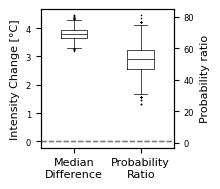

In [44]:
# ---------------------------------------------------------------------
# Bootstrap probability ratios for P(T >= observed)
# and plot as a box plot
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt


def bootstrap_probability_ratio(
    fact_values,
    cf_values,
    threshold,
    n_boot=2000,
    rng=None,
    correction=0.5,
):
    """
    Bootstrap the probability ratio

        PR = P_fact(T >= threshold) / P_cf(T >= threshold)

    using ensemble-member resampling with replacement.

    Parameters
    ----------
    fact_values : array-like
        Factual ensemble values for one day / region.
    cf_values : array-like
        Counterfactual ensemble values for one day / region.
    threshold : float
        Observed threshold temperature.
    n_boot : int
        Number of bootstrap resamples.
    rng : np.random.Generator or None
        Random number generator.
    correction : float
        Continuity correction to avoid division by zero when the
        counterfactual exceedance count is 0. Applied to both numerator
        and denominator counts as:
            p = (k + correction) / (n + 2 * correction)

    Returns
    -------
    pr_boot : ndarray
        Bootstrapped probability ratios.
    p_fact_boot : ndarray
        Bootstrapped factual exceedance probabilities.
    p_cf_boot : ndarray
        Bootstrapped counterfactual exceedance probabilities.
    """
    fact_values = np.asarray(fact_values).ravel()
    cf_values = np.asarray(cf_values).ravel()

    n_fact = fact_values.size
    n_cf = cf_values.size

    if rng is None:
        rng = np.random.default_rng()

    pr_boot = np.empty(n_boot, dtype=float)
    p_fact_boot = np.empty(n_boot, dtype=float)
    p_cf_boot = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        k_fact = np.sum(fact_sample >= threshold)
        k_cf = np.sum(cf_sample >= threshold)
        print("k_cf:", k_cf)

        # Continuity-corrected exceedance probabilities
        p_fact = (k_fact + correction) / (n_fact + 2 * correction)
        p_cf = (k_cf + correction) / (n_cf + 2 * correction)

        p_fact_boot[i] = p_fact
        p_cf_boot[i] = p_cf
        pr_boot[i] = p_fact / p_cf

    return pr_boot, p_fact_boot, p_cf_boot


# ---------------------------------------------------------------------
# Use existing values from your earlier code
# ---------------------------------------------------------------------
# Assumes these already exist:
#   fact_values
#   cf_values
#   fact_truth_ger
#   TEXT_FS

boot_median_diff = fact_boot_medians - cf_boot_medians
print("Median intensity change:", np.percentile(boot_median_diff, 50))


t_obs = float(fact_truth_ger.values)

pr_boot, p_fact_boot, p_cf_boot = bootstrap_probability_ratio(
    fact_values=fact_values,
    cf_values=cf_values,
    threshold=t_obs,
    n_boot=2000,
    rng=np.random.default_rng(123),
    correction=0.5,
)

# Summary stats
pr_median = np.median(pr_boot)
pr_q025 = np.percentile(pr_boot, 2.5)
pr_q25 = np.percentile(pr_boot, 25)
pr_q75 = np.percentile(pr_boot, 75)
pr_q975 = np.percentile(pr_boot, 97.5)

print(f"Observed threshold: {t_obs:.3f} °C")
print(f"Median PR: {pr_median:.3f}")
print(f"IQR: [{pr_q25:.3f}, {pr_q75:.3f}]")
print(f"95% CI: [{pr_q025:.3f}, {pr_q975:.3f}]")

# ---------------------------------------------------------------------
# Box plot
# ---------------------------------------------------------------------


fig, ax1 = plt.subplots(figsize=(2.3, 2.0))

# -------------------------------------------------
# Left axis: median difference
# -------------------------------------------------
lw=0.5

box1 = ax1.boxplot(
    boot_median_diff,
    positions=[1],
    widths=0.4,
    vert=True,
    showfliers=True,
    flierprops={
        "marker": "x",
        "markersize": lw,
        "markerfacecolor": "k",
        "markeredgecolor": "k",
        "alpha": 1.0},
    patch_artist=False,
    medianprops={"linewidth": lw, "color": "black"},
    boxprops={"linewidth": lw},
    whiskerprops={"linewidth": lw},
    capprops={"linewidth": lw},
)

ax1.axhline(0, color="gray", linestyle="--", linewidth=1)

ax1.set_ylabel(
    "Intensity Change [°C]", #\n(Factual − Counterfactual)",
    fontsize=8
)

ax1.tick_params(axis="y", labelsize=6)


# -------------------------------------------------
# Right axis: probability ratio
# -------------------------------------------------
ax2 = ax1.twinx()

box2 = ax2.boxplot(
    pr_boot,
    positions=[2],
    widths=0.4,
    vert=True,
    showfliers=True,
    flierprops={
        "marker": "x",
        "markersize": lw,
        "markerfacecolor": "k",
        "markeredgecolor": "k",
        "alpha": 1.0},
    patch_artist=False,
    medianprops={"linewidth": lw, "color": "black"},
    boxprops={"linewidth": lw},
    whiskerprops={"linewidth": lw},
    capprops={"linewidth": lw},
)

ax2.axhline(1, color="gray", linestyle="--", linewidth=1)

ax2.set_ylabel(
    "Probability ratio", #\n$P_{fact}(T ≥ T_{obs}) / P_{cf}(T ≥ T_{obs})$",
    fontsize=8
)

ax2.tick_params(axis="y", labelsize=6)


# -------------------------------------------------
# X axis formatting
# -------------------------------------------------
ax1.set_xticks([1, 2])
ax1.set_xticklabels(
    ["Median\nDifference", "Probability\nRatio"],
    fontsize=8
)

#ax1.text(0.05, 0.93, "(d)", transform=ax1.transAxes, fontsize=text_fs)

plt.tight_layout()
#plt.savefig("boxplot.pdf")
plt.show()

def bootstrap_intensity_shift(fact_values, cf_values, t_obs, n_boot=2000, rng=None):

    fact_values = np.asarray(fact_values)
    cf_values = np.asarray(cf_values)

    n_fact = len(fact_values)
    n_cf = len(cf_values)

    if rng is None:
        rng = np.random.default_rng()

    delta = np.empty(n_boot)

    for i in range(n_boot):

        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        p_fact = np.mean(fact_sample >= t_obs)
        t_cf_equiv = np.quantile(cf_sample, 1 - p_fact)

        delta[i] = t_obs - t_cf_equiv

    return delta


delta_boot = bootstrap_intensity_shift(
    fact_values,
    cf_values,
    t_obs,
    n_boot=2000,
    rng=np.random.default_rng(0)
)



Factual risk mean: 2.4804998693408518
CF risk mean: 0.4411776856454799
risk signal: 2.039322183695372


/tmp/ipykernel_2754414/2239046210.py:143: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x=float(cf_truth_ger.values),
/tmp/ipykernel_2754414/2239046210.py:150: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x=float(fact_truth_ger.values),


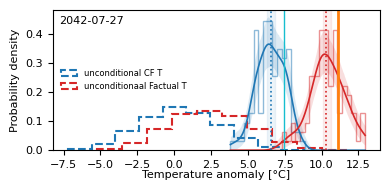

In [45]:
# ---------------------------------------------------------------------
# Plot histogram + KDE CI + mean/median/truth lines
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4,2))

# Histograms as one-line outlines
ax.hist(
    cf_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1,
    alpha=0.5,
    color="tab:blue",
    #label="CF ensemble",
)
ax.hist(
    fact_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1,
    alpha=0.5,
    color="tab:red",
    #label="Factual ensemble",
)

#############################
### risk-based Histograms ###
#############################
a_risk = trefht_le_cf_0627_ger.values.flatten()
b_risk = trefht_le_fact_0627_ger.values.flatten()

print("Factual risk mean:", np.mean(b_risk))
print("CF risk mean:", np.mean(a_risk))
print("risk signal:", np.mean(b_risk) - np.mean(a_risk))


ax.hist(
    a_risk,
    density=True,
    histtype="step",
    linewidth=1.5,
    label="unconditional CF T",
    color="tab:blue",
    linestyle="--"
)

ax.hist(
    b_risk,
    density=True,
    histtype="step",
    linewidth=1.5,
    label="unconditionaal Factual T",
    color="tab:red",
    linestyle="--"
)

# KDE confidence intervals
ax.fill_between(
    x,
    cf_kde_low,
    cf_kde_high,
    color="tab:blue",
    alpha=0.15,
    linewidth=0,
    #label="CF KDE 95% CI",
)
ax.fill_between(
    x,
    fact_kde_low,
    fact_kde_high,
    color="tab:red",
    alpha=0.15,
    linewidth=0,
    #label="Factual KDE 95% CI",
)

# KDE lines from original ensemble
ax.plot(
    x,
    cf_kde,
    color="tab:blue",
    linewidth=1.2,
    #label="CF KDE",
)
ax.plot(
    x,
    fact_kde,
    color="tab:red",
    linewidth=1.2,
    #label="Factual KDE",
)

# Single ensemble mean vertical lines
#ax.axvline(
#    x=float(cf_single_ensemble_mean_ger.values),
#    color="tab:blue",
#    linestyle="--",
#    linewidth=1.0,
#    label="CF single\nensemble mean",
#)
#ax.axvline(
#    x=float(fact_single_ensemble_mean_ger.values),
#    color="tab:red",
#    linestyle="--",
#    linewidth=1.0,
#    label="Factual single\nensemble mean",
#)

# Bootstrap median vertical lines
ax.axvline(
    x=float(cf_boot_median),
    color="tab:blue",
    linestyle=":",
    linewidth=1.2,
    #label="CF bootstrap\nmedian",
)
ax.axvline(
    x=float(fact_boot_median),
    color="tab:red",
    linestyle=":",
    linewidth=1.2,
    #label="Factual bootstrap\nmedian",
)

# Optional: CI of the bootstrapped medians as shaded x-ranges
ax.axvspan(
    cf_median_ci_low,
    cf_median_ci_high,
    color="tab:blue",
    alpha=0.08,
)
ax.axvspan(
    fact_median_ci_low,
    fact_median_ci_high,
    color="tab:red",
    alpha=0.08,
)

# Truth lines
ax.axvline(
    x=float(cf_truth_ger.values),
    color="tab:cyan",
    linestyle="-",
    linewidth=1.0,
    #label="Circulation-nudged\nheatwave",
)
ax.axvline(
    x=float(fact_truth_ger.values),
    color="tab:orange",
    linestyle="-",
    linewidth=2.0,
    #label="Heatwave",
)

# Formatting
ax.set_xlabel("Temperature anomaly [°C]", fontsize=8, labelpad=0)
ax.set_ylabel("Probability density", fontsize=8)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)
#ax.text(0.02, 0.9, f"(c)", transform=ax.transAxes, fontsize=TEXT_FS)
#x.text(0.02, 1.025, f"{DATE}", transform=ax.transAxes, fontsize=6)
ax.text(0.02, 0.9, f"{DATE}", transform=ax.transAxes, fontsize=8)


#ax.legend(
#    loc="center left",
#    bbox_to_anchor=(0.99, 0.5),
#    frameon=False,
#    fontsize=16,
#)

from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class HandlerTwoColorPatch(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        r1 = Rectangle(
            (xdescent, ydescent), width/2, height,
            facecolor="tab:blue", alpha=0.15, transform=trans
        )
        r2 = Rectangle(
            (xdescent + width/2, ydescent), width/2, height,
            facecolor="tab:red", alpha=0.15, transform=trans
        )

        return [r1, r2]

ci_handle = object()

handles, labels = ax.get_legend_handles_labels()

handles.append(ci_handle)
#labels.append("KDE 95% CI")

ax.legend(
    handles,
    labels,
    handler_map={ci_handle: HandlerTwoColorPatch()},
    loc="center left",
    #bbox_to_anchor=(0.99, 0.5),
    frameon=False,
    fontsize=6,
)

#ci_patch = Patch(
#    facecolor="gray",
#    alpha=0.15,
#    label="KDE 95% CI"
#)

#handles, labels = ax.get_legend_handles_labels()
#handles.append(ci_patch)
#labels.append("KDE 95% CI")

#ax.legend(
#    handles,
#    labels,
#    loc="center left",
#    bbox_to_anchor=(0.99, 0.5),
#    frameon=False,
#    fontsize=16,
#)

fig.subplots_adjust(right=0.75)
plt.tight_layout()
#plt.savefig("cond_distrs_and_risk_hists.pdf")
plt.show()

## Plot timeseries

In [46]:
# indices of maximum absolute temperatures
#idx_abs = np.load("yearly_absolute_max_indices_ger.npy")
import xarray as xr
ds_1300 = xr.open_dataset("/work2/fl53wumy-llaae_ws_new/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/eth_test_trefht_data/TREFHT_day_b.e212.BHISTcmip6andSSP370cmip6.f09_g17.1300.nc")
ds_1300


<xarray.Dataset> Size: 20GB
Dimensions:    (time: 91615, bnds: 2, lon: 288, lat: 192)
Coordinates:
  * time       (time) object 733kB 1850-01-01 00:00:00 ... 2100-12-31 00:00:00
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 1MB ...
    TREFHT     (time, lat, lon) float32 20GB ...
Attributes:
    CDI:               Climate Data Interface version 1.9.6 (http://mpimet.mp...
    Conventions:       CF-1.0
    history:           Fri Sep 29 17:03:30 2023: cdo -O -mergetime /net/h2o/c...
    source:            CAM
    case:              b.e212.BHISTcmip6.f09_g17.1300
    logname:           beyerleu
    initial_file:      b.e212.B1850cmip6.f09_g17.001.cam.i.1300-01-01-00000.nc
    topography_file:   /cluster/work/climate/cesm/inputdata/atm/cam/topo/fv_0...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1
    CDO:               Climate Data Operators version 1.9.6 (http://mpimet.mp...

In [47]:
trefht_1300_abs = ut.get_ger_1d_data(ds_1300.TREFHT)
trefht_1300_abs

<xarray.DataArray 'TREFHT' (time: 91615)> Size: 733kB
array([277.9163743 , 277.40003626, 276.12869657, ..., 279.19536146,
       282.55132301, 285.26384028], shape=(91615,))
Coordinates:
  * time     (time) object 733kB 1850-01-01 00:00:00 ... 2100-12-31 00:00:00

In [48]:
# compute 5 day windows and compute mean 
ds_5day = trefht_1300_abs.resample(time="5D", label="left").mean()
print(ds_5day)
ds_5day = ds_5day.assign_coords(time=ds_5day.time + pd.Timedelta(days=2, hours=12))
ds_5day_jja = ds_5day.sel(time=ds_5day.time.dt.month.isin([6, 7, 8]))

<xarray.DataArray 'TREFHT' (time: 18323)> Size: 147kB
array([278.04761869, 280.21337129, 277.04075355, ..., 278.35046744,
       276.10902525, 280.7989015 ], shape=(18323,))
Coordinates:
  * time     (time) object 147kB 1850-01-01 00:00:00 ... 2100-12-27 00:00:00


/tmp/ipykernel_2754414/1428465313.py:5: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_2754414/1428465313.py:5: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_2754414/1428465313.py:17: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argu

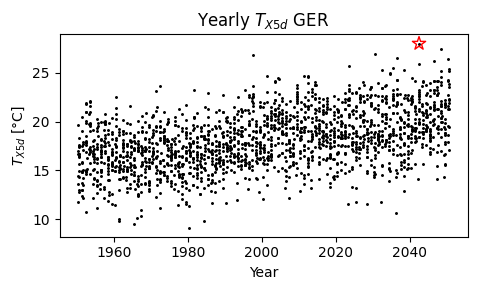

In [50]:
ds_5day_jja_celsius = ds_5day_jja.sel(time=slice("1950","2050"))-273.15

scale=1.5
fig, ax = plt.subplots(figsize=(scale*3.25, scale*2))
time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()

#ds_5day_jja_celsius.plot.scatter(ax=ax,color='k', marker='.',s=5, linewidth=0.4, label="Maximum T")
#ds_5day_jja_celsius.sel(time=date_text).plot.scatter(ax=ax,
#                                                     marker='*',
#                                                     facecolors='none',
#                                                     edgecolors='red',
#                                                     s=100,            # size
#                                                     linewidths=1
#                                                    ) 
ax.scatter(time, ds_5day_jja_celsius.values, marker='.',s=5, color='k', label="Maximum T")
hw = ds_5day_jja_celsius.sel(time=date_text)
hw_time = hw.indexes["time"].to_datetimeindex()
ax.scatter(hw_time, hw.values,
           marker='*',
           facecolors='none',
           edgecolors='red',
           s=100,linewidths=1)

ax.set_ylabel(r"$T_{X5d}$ [°C]")
ax.set_xlabel("Time [years]")
ax.set_title(r"Yearly $T_{X5d}$ GER")
ax.set_ylabel(r"$T_{X5d}$ [°C]")
ax.set_xlabel("Year")
plt.tight_layout()
#plt.savefig("/FR_T_ts_absolute.pdf")



<xarray.DataArray 'TREFHT' (year: 11)> Size: 88B
array([24.44495253, 24.21759637, 28.01413572, 24.20149467, 23.7166244 ,
       23.95746529, 26.19775814, 24.12837475, 27.48030423, 22.26548966,
       26.43799407])
Coordinates:
  * year     (year) int64 88B 2040 2041 2042 2043 2044 ... 2047 2048 2049 2050

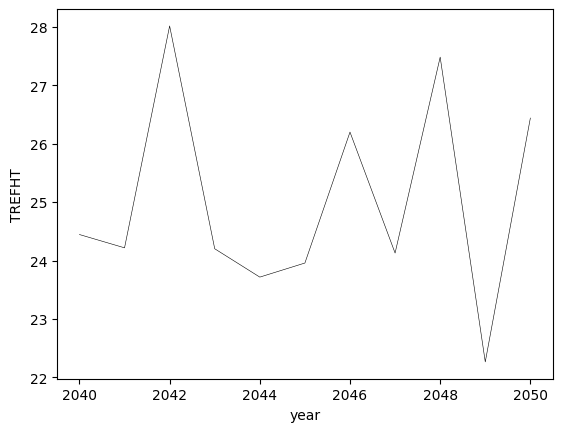

In [25]:
max_temps = ds_5day_jja_celsius.sel(time=slice("2040","2050")).groupby("time.year").max(dim="time")
max_temps.plot(color='k', linestyle='-', linewidth=0.4, label="Maximum T")
max_temps